<a href="https://colab.research.google.com/github/avega17/CCOM6994_PV_Solar_Project/blob/main/solar_pv_census_data_analysis_E2E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup, Dataset Fetch and Pre-processing to Enable End to End Analysis in a Single Notebook

In [1]:
# install git python package to fetch our repository for required data fetching and preprocessing scripts (cant rely on classmates having git cli installed)
# give preference to uv but use pip when not installed
import shutil
import os
import time
import random

uv_path = shutil.which("uv")
if uv_path is not None:
    print("Installing GitPython via uv...")
    !uv pip install GitPython
else:
    print("Installing GitPython via pip...")
    !pip install GitPython

local_path = "pv_solar_analysis/"
# delete directory if it exists to ensure fresh clone and easier notebook re-runs
if os.path.exists(local_path):
    shutil.rmtree(local_path, ignore_errors=True)

Installing GitPython via uv...
Using Python 3.12.12 environment at: /usr
Audited 1 package in 154ms


In [2]:
# fetch requirements and pre-processing notebooks from github
from git import Repo

# Replace with your repository URL and desired local path
repo_url = "https://github.com/avega17/CCOM6994_PV_Solar_Project.git"
# NOTE: adjust local_path as needed

repo_name = repo_url.split("/")[-1].replace(".git", "")
if not os.path.exists(local_path):
    os.mkdir(local_path)

try:
    Repo.clone_from(repo_url, local_path)
    # remove the .git folder to avoid confusion and conflict during team development
    shutil.rmtree(f"{local_path}/.git", ignore_errors=True)
    print(f"Repository cloned successfully to {local_path}")

except Exception as e:
    print(f"Error cloning repository: {e}")

Repository cloned successfully to pv_solar_analysis/


In [3]:
# install requirements
if uv_path is not None:
    print("Installing requirements via uv...")
    !uv pip install -r {local_path}requirements.txt
else:
    print("Installing requirements via pip...")
    !pip install -r {local_path}requirements.txt

Installing requirements via uv...
Using Python 3.12.12 environment at: /usr
Audited 31 packages in 307ms


<div align="center">

## Universidad de Puerto Rico Río Piedras

## Departamento de Ciencia de Cómputos

## CCOM6994: Herramientas Computacionales para el Análisis de Datos

</div>

<div align="center">

------------------------------------------------------------------------------

# Analisis de Instalaciones de Paneles Solares Fotovoltaicos (FV) en EEUU y sus territorios:  

## Distribución de Cubiertas de Suelo y Uso de Tierra de las instalacions  
## y Pruebas Estadisticas entre las Poblaciones con y sin presencia de sistemas FV  
## agrupadas por divisones del Censo 2020
</div>

-----------------------------------------------------------------------------------

#### Miembros del Equipo:

- Alejandro S. Vega Nogales
- Francheska I. Lebrón López
- Nicole M. Ramírez Mulero
- Luis M. Fontán Rodríguez



In [4]:
import pandas as pd
import numpy as np
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import geopandas as gpd
from shapely import wkt, wkb
from shapely.geometry import Point, box
from dotenv import load_dotenv, set_key

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import HBox, VBox, Button, Text, Output, Layout

In [5]:
# configuracion de variables del archivo .env que descargamos de github
dot_env_path = os.path.join(local_path, '.env')


# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# create db dir if not exists
db_dir = os.path.join(os.getcwd(), local_path, 'db')
os.makedirs(db_dir, exist_ok=True)
# fix DB_PATH in the .env file for colab
if 'google.colab' in str(get_ipython()):
    DB_PATH = os.path.join(db_dir, 'pv_project.duckdb')
    # also modify .env var of same name for .py notebook scripts
    set_key(dot_env_path, 'PROJECT_DB', DB_PATH)
    load_dotenv(dotenv_path=dot_env_path)
else:
    load_dotenv(dotenv_path=dot_env_path)
    DB_PATH = os.getenv('DEMO_DB_PATH', 'db/pv_project.duckdb')

print(f"Using {DB_PATH} for DuckDB")


DATASET_URI = os.getenv('CONSOLIDATED_PV_DATASET_FILE', 'https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet')

GEOM_TYPE = ''

Using /content/pv_solar_analysis/db/pv_project.duckdb for DuckDB


In [6]:
# show current working dir; useful for Colab
print(os.getcwd())
# list the dir and repo dir we created and fetched
print(os.listdir())

/content
['.config', 'pv_solar_analysis', 'sample_data']


---

## 📥 Tarea 0: Descargar nuestro conjunto e Intro Breve a Datos Geoespaciales
### Acerca de Nuestro Conjunto de Datos

Estamos trabajando con un **conjunto de datos consolidado global de paneles solares (PV)** que incluye:
- Localizaciones y metadatos de instalaciones FV alrededor del mundo provenientes de publicaciones científicas y datos abiertos
- Coordenadas geográficas y límites de polígonos de las instalaciones
- Metadatos de instalación (área, capacidad, fechas de instalación)
- Estos serán filtrados espacialmente para centrarse en los EE.UU. y sus territorios para nuestro análisis.

### Formato de Datos: GeoParquet

**GeoParquet** es un formato eficiente y nativo en la nube para datos geoespaciales:
- Almacenamiento columnar y compresión eficiente
- Metadatos espaciales integrados (CRS, cajas delimitadoras)
- Funciona con pandas, GeoPandas, DuckDB y otras herramientas
- Almacenado en **Cloudflare R2** (compatible con S3; 5GB gratis mensuales)

### Estrategia de Lectura

Usaremos **pandas** para leer el archivo parquet via https URL:
1. Leer el archivo parquet en un DataFrame de pandas
2. Convertir cadenas de geometría WKT o WKB a objetos Shapely que GeoPandas reconoce
3. Crear un GeoDataFrame con el sistema de referencia de coordenadas (CRS) adecuado

In [7]:
# Fetch and Filter
t1 = time.time()
pv_df = pd.read_parquet(DATASET_URI, engine='pyarrow')
t2 = time.time()
print(f"Datos se descargaron en {t2 - t1:.2f} segundos.")
global_count = len(pv_df)
print(f"En total tenemos {global_count:,} instalaciones fotovoltaicas del conjunto de datos global.")

# Display count by dataset
print("\nConteos por Fuente de los Datos:")
print(pv_df.groupby('dataset_name').size())

# Display basic info
print(f"\n📊 Conjunto de Datos:")
print(f"   Dimensiones: {pv_df.shape}")
print(f"   Espacio en Memoria: {pv_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Columnas: {pv_df.dtypes}")

# Summary statistics for numeric columns
print("\n📈 Estadísticas Resumidas:\n")
display(pv_df.describe())

Datos se descargaron en 19.95 segundos.
En total tenemos 280,761 instalaciones fotovoltaicas del conjunto de datos global.

Conteos por Fuente de los Datos:
dataset_name
global_harmonized_large_solar_farms_2020     35271
global_pv_inventory_sent2_spot_2021         119057
global_pv_ms_planetscope_2025                86336
usa_cali_usgs_pv_2016                        19373
usa_eia_large_scale_pv_2023                   5707
usa_gm_seus_v1_2025                          15017
dtype: int64

📊 Conjunto de Datos:
   Dimensiones: (280761, 11)
   Espacio en Memoria: 1181.4 MB

   Columnas: dataset_name              object
geometry                  object
centroid_lon             float64
centroid_lat             float64
area_m2                  float64
processed_at      datetime64[us]
unified_id                object
source_area_m2           float64
capacity_mw              float64
install_date      datetime64[ns]
h3_index_12                Int64
dtype: object

📈 Estadísticas Resumidas:



,centroid_lon,centroid_lat,area_m2,processed_at,source_area_m2,capacity_mw,install_date,h3_index_12
count,280756.000000,280756.000000,2.807610e+05,280761,1.950940e+05,101428.000000,39359,280756.0
mean,14.031758,38.852039,1.744860e+05,2025-12-03 15:31:56.342306,1.257340e+05,8.084826,1992-05-30 15:17:37.252471808,631335055398861824.0
min,-177.927191,-53.200533,0.000000e+00,2025-12-03 15:31:49.868593,0.000000e+00,0.001250,1970-01-01 00:00:00.000001985,630524014821282304.0
25%,-73.238995,34.904460,1.297935e+03,2025-12-03 15:31:54.053327,7.753353e+03,0.564323,1970-01-01 00:00:00.000002018,631051393436115456.0
50%,12.650158,38.637561,2.542452e+04,2025-12-03 15:31:54.929909,2.113185e+04,1.609335,1970-01-01 00:00:00.000002024,631237224568096768.0
75%,108.966232,47.353472,8.394201e+04,2025-12-03 15:32:02.144957,6.036185e+04,4.654102,2017-02-27 00:00:00,631376797472753792.0
max,177.981774,69.755046,3.778312e+08,2025-12-03 15:32:02.144957,1.709438e+08,3059.321862,2018-12-12 00:00:00,634454735953692160.0
std,86.082976,12.132497,1.717880e+06,NaN,9.807897e+05,33.108487,NaN,403662725081102.1875


In [8]:
pv_df.sample(5)

,dataset_name,geometry,centroid_lon,centroid_lat,area_m2,processed_at,unified_id,source_area_m2,capacity_mw,install_date,h3_index_12
11030,usa_cali_usgs_pv_2016,POLYGON ((-119.72825276282867 36.8316912724560...,-119.728289,36.831693,41.808743,2025-12-03 15:31:49.868593,usa_cali_usgs_pv_2016_00011030,26.752687,NaN,NaT,631237019464716799
268524,global_pv_ms_planetscope_2025,POLYGON ((-72.92080878193013 42.52050974388022...,-72.920044,42.519671,57216.588139,2025-12-03 15:32:02.144957,global_pv_ms_planetscope_2025_00268524,31063.706161,NaN,NaT,631246288259134976
240443,global_pv_ms_planetscope_2025,POLYGON ((13.624591825556488 43.05110912741981...,13.623418,43.049936,38501.948221,2025-12-03 15:32:02.144957,global_pv_ms_planetscope_2025_00240443,20550.755435,NaN,NaT,631040853970816512
102750,global_pv_inventory_sent2_spot_2021,POLYGON ((115.23378507190382 40.53739698315981...,115.233952,40.537428,879.021445,2025-12-03 15:31:54.929909,global_pv_inventory_sent2_spot_2021_00102750,507.698147,0.053862,2017-08-21,631377195761669631
245839,global_pv_ms_planetscope_2025,"POLYGON ((7.810678481027056 49.94895554900049,...",7.811220,49.947508,188310.358491,2025-12-03 15:32:02.144957,global_pv_ms_planetscope_2025_00245839,78064.434263,NaN,NaT,631061315683708416


**Columnas Claves:**

- `geometry` contiene strings WKT (*Well-Known Text*) que definen geometrías (Puntos, Líneas, Polígonos)
- `centroid_lon`, `centroid_lat`: En datos geoespaciales, las geometrías se definen por coordenadas geográficas. Los centroides representan el "centro" de estas geometrías.
- `area_m2` muestra el tamaño del panel en metros cuadrados
- `h3_index_8` contiene el índice espacial H3 (lo exploraremos más adelante)
- `installation_date` indica cuándo se instaló el panel solar
- `capacity_kw` muestra la capacidad de generación nominal en kilovatios (kW)

## GeoPandas, Geometrías, y Datos Geoespaciales

Como indica el nombre, GeoPandas extiende pandas para manejar datos geoespaciales de manera eficiente.  

La estructura de datos principal son el *GeoDataFrame* y la *GeoSeries*: clases derivadas de pandas DataFrame y Series que almacenan geometrías y tienen métodos para operaciones espaciales:
- Data Members para: area, delimitación geométrica, centroide, etc
- Funciones y relaciones espaciales: distancia, intersección, contención, unión espacial, etc
- Manejo de sistemas de referencia de coordenadas (CRS): El manejo adecuado de CRS es crucial en datos geoespaciales para asegurar que las coordenadas y geometrías se interpreten correctamente.
<!-- GeoPandas facilita la transformación entre diferentes CRS. -->

En la siguiente celda realizamos un pre-procesamiento requerido para convertir geometrías de su representación en almacénamiento (WKT o WKB) a representaciones de geometrías en memoria que GeoPandas puede utilizar.

In [9]:
# load WKT geometries as shapely objects
if pv_df['geometry'].dtype == 'object' and isinstance(pv_df['geometry'].iloc[0], str):
    pv_df['geometry'] = pv_df['geometry'].apply(wkt.loads)
    GEOM_TYPE = 'WKT'
# load WKB geometries as shapely objects
elif pv_df['geometry'].dtype == 'object' and isinstance(pv_df['geometry'].iloc[0], bytes):
    pv_df['geometry'] = pv_df['geometry'].apply(wkb.loads)
    GEOM_TYPE = 'WKB'

pv_gdf = gpd.GeoDataFrame(pv_df, geometry='geometry', crs='EPSG:4326')

#### Visualización de Muestras Aleatorias de Geometrías

In [10]:
# types of geometries in our data
geom_types = pv_gdf.geometry.geom_type.value_counts()
print("Tipos de geometrías en nuestros datos:")
display(geom_types)

Tipos de geometrías en nuestros datos:


,count
Polygon,256458
MultiPolygon,13778
MultiPoint,5640
Point,4885


In [11]:
# Filter for Polygons only to avoid issues with MultiPolygons in simple plot
poly_subset = pv_gdf[pv_gdf.geometry.type == 'Polygon']
sample_polys = poly_subset.sample(n=6, random_state=42)

# create a simple button to re-run the plot function interactively
button = widgets.Button(description="Visualizar Muestra", layout=Layout(width='200px'))
output = widgets.Output()

def plot_poly_geoms(sample_polys):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (i, row) in enumerate(sample_polys.iterrows()):
        ax = axes[idx]
        # Plot the geometry
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color='skyblue', edgecolor='black', alpha=0.6)
        display_name = row['dataset_name'].split('_')[0] + '_'.join(row['dataset_name'].split('_')[3::])
        ax.set_title(f"Fuente: {display_name}...\nArea: {row['area_m2']:.0f} m²")
        ax.axis('off')

    plt.tight_layout()
    # Save to a specific directory to avoid cluttering root
    # plt.savefig('/Volumes/Expanse/repos/ice-mELT_ducklake/notebooks/01_polygon_samples.png', dpi=150, bbox_inches='tight')
    # print("💾 Saved plot: 01_polygon_samples.png")
    plt.show()

def on_button_clicked(b):
    clear_output(wait=True)
    sample_polys = poly_subset.sample(n=6, random_state=random.randint(0,10000))
    plot_poly_geoms(sample_polys)
    display(button)

button.on_click(on_button_clicked)

with output:
    plot_poly_geoms(sample_polys)
    display(button)

display(output)

Output()

### Manipulación de GeoDataFrames con indices

Además de las operaciones que hereda de Pandas como `.iloc` y `.loc`, GeoPandas permite la indexación basada en coordenadas espaciales usando `.cx` como demostramos a continuación limitando nuestro conjunto de datos a varias areas de interés (AOI) en los Estados Unidos y sus territorios.

In [12]:
# Collection of bounding boxes covering USA (including PR,HI,AK,Guam+USVI)
# Format: (xmin/west, ymin/south, xmax/east, ymax/north) in WGS84 degrees
AOI_bboxes = [
    os.getenv('CONUS_BBOX', '-125.0,24.0,-66.5,49.5'),  # CONUS
    os.getenv('ALASKA_BBOX', '-170.0,51.0,-130.0,72.0'),  # Alaska
    os.getenv('HAWAII_BBOX', '-161.0,18.5,-154.5,23.0'),  # Hawaii
    os.getenv('GUAM_BBOX', '144.5,13.2,145.0,13.6'),  # Guam
    os.getenv('USVI_BBOX', '-65.1,17.6,-64.5,18.6'),   # US Virgin Islands
    os.getenv('PUERTO_RICO_BBOX', '-67.3,17.9,-65.2,18.5')  # Puerto Rico
]
# Parse AOI bounding boxes into list of float tuples
AOI_bboxes = [ tuple(map(float, bbox_str.split(','))) for bbox_str in AOI_bboxes ]


t1 = time.time()
# Coordinate based indexer to select by intersection with bounding box: https://geopandas.org/en/stable/docs/user_guide/indexing.html
# apply indexing via all bboxes and concatenate into single gdf
pv_df = pd.concat([pv_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]] for bbox in AOI_bboxes])

# handle geometry column for gdf since we converted to pandas during concat
# pv_df['geometry'] = pv_df['geometry'].apply(wkt.loads) if GEOM_TYPE == 'WKT' else pv_df['geometry'].apply(wkb.loads)

# use global geographic CRS for now; TODO: ID relevant CRS's for CONUS, caribbean, and pacific regions
pv_gdf = gpd.GeoDataFrame(pv_df, geometry='geometry', crs='EPSG:4326')
t2 = time.time()
# Filter by Bounding Box
print(f"Utilizamos indexación con coordenadas para eliminar {global_count - len(pv_gdf):,} instalaciones fuera de nuestras {len(AOI_bboxes)} AOI's en {t2 - t1:.2f} segundos...")

Utilizamos indexación con coordenadas para eliminar 205,597 instalaciones fuera de nuestras 6 AOI's en 0.60 segundos...


#### Vamos a darle un vistazo a nuestro nuevo subconjunto mediante un geo-scatter plot interactivo utilizando `plotly`:

In [13]:
# crea instancia de un scatter plot con un mapa base interactivo
fig = px.scatter_map(
    pv_gdf,
    lat='centroid_lat',
    lon='centroid_lon',
    zoom=2,
    height=800,
    width=1000,
    color='dataset_name',
    opacity=0.45
)

# plot multiple AOIs in global map
for AOI_BBOX in AOI_bboxes:

    # add bbox as line trace
    fig.add_trace(
        px.scatter_map(
            pd.DataFrame({
                'lon': [AOI_BBOX[0], AOI_BBOX[2], AOI_BBOX[2], AOI_BBOX[0], AOI_BBOX[0]],
                'lat': [AOI_BBOX[1], AOI_BBOX[1], AOI_BBOX[3], AOI_BBOX[3], AOI_BBOX[1]]
            }),
            lat='lat',
            lon='lon'
        ).data[0]
    )

    # update bbox line style
    fig.data[-1].update(
        mode='lines',
        line=dict(color='red', width=2),
        showlegend=False
    )

# show final map with AOI bounding boxes
fig.update_layout(title="Localizaciones de Instalaciones Fotovoltaicas en el Conjunto de Datos Consolidado con AOI's Destacadas")
# config map projection and other geo config
fig.update_geos(projection_type="orthographic")
# use pre-configred mapbox style
# fig.update_layout(mapbox_style="satellite-streets")
fig.show()

#### Deduplicación de instalaciones fotovoltaicas basadas en geometrías

Ya que estamos trabajando con un conjunto de datos consolidado de múltiples fuentes, es posible que existan instalaciones fotovoltaicas duplicadas o muy cercanas entre sí. Para asegurar la integridad de nuestro análisis, implementaremos una estrategia de deduplicación basada en la proximidad espacial.

In [14]:
# Check for exact duplicates in geometry
initial_count = len(pv_gdf)
print(f"   Conteo de filas inicial: {initial_count:,}")

# see here for recommended approach for deduplication: https://geopandas.org/en/latest/docs/user_guide/how_to.html
pv_gdf['geometry'] = pv_gdf['geometry'].normalize()
# Note: This can be slow for large datasets as it compares every geometry
pv_gdf_dedup = pv_gdf.drop_duplicates(subset=['geometry'], inplace=False, ignore_index=True)
num_duplicates = initial_count - len(pv_gdf_dedup)


print(f"   Duplicados con geometrías idénticas: {num_duplicates:,}")

# pv_gdf_dedup = pv_gdf[~duplicates_mask].copy()
print(f"   Conteo después de la deduplicación con GeoPandas: {len(pv_gdf_dedup):,}")

# remove invalid geometries before saving
og_len = len(pv_gdf_dedup)
pv_gdf_dedup = pv_gdf_dedup[pv_gdf_dedup.is_valid].copy()
print(f"   Eliminamos {og_len - len(pv_gdf_dedup):,} geometrías inválidas antes de guardar.\n")
print(f"Distribución de los datos por fuente después de la limpieza:")
display(pv_gdf_dedup['dataset_name'].value_counts())

   Conteo de filas inicial: 75,164
   Duplicados con geometrías idénticas: 768
   Conteo después de la deduplicación con GeoPandas: 74,396
   Eliminamos 0 geometrías inválidas antes de guardar.

Distribución de los datos por fuente después de la limpieza:


,count
dataset_name,
usa_cali_usgs_pv_2016,19373
global_pv_inventory_sent2_spot_2021,18402
usa_gm_seus_v1_2025,15013
global_pv_ms_planetscope_2025,11667
usa_eia_large_scale_pv_2023,5707
global_harmonized_large_solar_farms_2020,4234


### Ahora almacenamos el conjunto de datos en DuckDB, una base de datos en un solo archivo para el resto del pre-procesamiento fuera de esta libreta

In [15]:
# Connect to persistent DB file
con_persistent = duckdb.connect(DB_PATH)
# install spatial and httpfs extensions
con_persistent.execute("INSTALL spatial; LOAD spatial;")

# Convert geometry to WKB for DuckDB storage
pv_gdf_dedup['geometry'] = pv_gdf_dedup['geometry'].apply(lambda geom: geom.wkb)

# process reading WKB/WKT geometry into Geometry data type for duckdb
# save as WKT for compatibility and easier retrieval wi
con_persistent.execute("""
    CREATE OR REPLACE TABLE processed_pv_data AS
        SELECT ST_GeomFromWKB(geometry) as geometry, * EXCLUDE (geometry) FROM pv_gdf_dedup
    """)
con_persistent.close()
print("   ✅ Almacenamos nuestros datos en la tabla 'processed_pv_data' de DuckDB")
# delete dataframes so far since we'll load the final processed data from duckdb in next steps
try:
    del pv_gdf_dedup
    del pv_gdf
    del pv_df
except NameError:
    pass

/tmp/ipython-input-1763973677.py:7: UserWarning:

Geometry column does not contain geometry.



   ✅ Almacenamos nuestros datos en la tabla 'processed_pv_data' de DuckDB


## ⚙️ 1: Pre-procesamiento para relacionar nuestro conjunto de datos con los Datos Geográficos y Demográficos

Uno de los aspectos más poderosos de los datos geoespaciales es la capacidad de relacionar diferentes conjuntos de datos basados en su proximidad espacial. En esta sección, realizaremos un pre-procesamiento para relacionar nuestro conjunto de datos de instalaciones fotovoltaicas con las fuentes de las variables geográficas y demográficas que utilizaremos en nuestro análisis estadístico a continuación.

Estas fuentes incluyen:
1. Censo de los EE.UU. 2020 a nivel de estado, county, y census tracto  

2. Cubiertas de Suelo con resolución de 10 metros derivadas del ESA WorldCover 2020 (distribuido por [Overture Maps](https://docs.overturemaps.org/blog/2024/05/16/land-cover/))  

3. Clasificaciones del Uso de Tierra obtenidas a través de OpenStreetMap (OSM) y procesadas por [Overture Maps](https://docs.overturemaps.org/guides/base/)

## 📚 Conceptual Framework: Socioeconomic Factors & Solar Adoption

Research suggests several socioeconomic factors influence solar panel adoption:

| Factor | Census Variable Groups | Hypothesis |
|--------|----------------------|------------|
| **Income** | B19013 (Median HH Income) | Higher income → higher adoption (upfront costs) |
| **Poverty** | B17001 (Poverty Status) | Higher poverty → lower adoption |
| **Housing** | B25077 (Home Value), B25003 (Tenure) | Homeowners more likely to install solar |
| **Education** | B15003 (Educational Attainment) | Higher education → more awareness |
| **Demographics** | B01003 (Population), B03002 (Race/Ethnicity) | Adoption patterns may vary by demographics |

In [16]:
# run our script for reverse geocoding and attaching the census state, county, and tract columns we need to match with census data during our statistical analysis
!python {local_path}notebooks/02_geocoding_census_geographies.py

📂 Connecting to database: /content/pv_solar_analysis/db/pv_project.duckdb
   Tables found: ['processed_pv_data']
   Loading 'processed_pv_data'...
   Converting 'geometry' from WKT to Shapely geometries...
✅ Loaded 74,396 rows into GeoDataFrame.
🌍 Running Offline Reverse Geocoding...
Loading formatted geocoded file...
✅ Geocoded 74,396 points in 0.92s using reverse_geocoder library.

📊 Top Countries found:
country_code
US    73056
CA      954
MX      273
PR       89
VI       11
Name: count, dtype: int64

📊 Top States found:
rg_state
California        30164
Arizona            6547
North Carolina     4224
Massachusetts      3786
New York           2576
New Jersey         2563
Minnesota          2029
Colorado           1986
Texas              1803
New Mexico         1392
Name: count, dtype: int64
✅ Geocoded 15 points in 19.63s using geopandas reverse_geocode.
🌐 Unique Countries Found: ['US', 'MX', 'CA', 'GU', 'VI', 'VG', 'PR', 'DO']
🎯 Filtering our dataset to Target Countries: ['US', 'GU'

In [17]:
 # preview census-enriched PV data from our local database
print("📥 Cargando datos enriquecidos con identificadores del Censo desde la base de datos...")

con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")

# Query the census-enriched PV data
pv_census_df = con.execute("""
    SELECT
        ST_AsText(geometry) as geometry,
        * EXCLUDE (geometry)
    FROM census_enriched_pv_data
""").df()

print(f"✅ Cargamos {len(pv_census_df):,} instalaciones FV con identificadores del Censo.")
print(f"\n📊 Columnas añadidas por el script de geocodificación:")
census_cols = ['country_code', 'rg_state', 'rg_county', 'STATE_FIPS', 'STATE_ABBR', 'STATE_GEOID',
               'COUNTY_FIPS', 'COUNTY_GEOID', 'COUNTY_NAME', 'TRACT_CODE', 'TRACT_GEOID', 'TRACT_NAME']
print(f"   {census_cols}")

# Show sample of enriched data
print(f"\n📋 Muestra de datos enriquecidos:")
display(pv_census_df[['dataset_name', 'centroid_lat', 'centroid_lon', 'STATE_ABBR', 'COUNTY_NAME', 'TRACT_GEOID']].sample(5))

# Show counts by state
print(f"\n📊 Distribución de instalaciones FV por estado:")
state_counts = pv_census_df.groupby('STATE_ABBR').size().sort_values(ascending=False)
display(state_counts.head(10))

con.close()

📥 Cargando datos enriquecidos con identificadores del Censo desde la base de datos...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Cargamos 73,165 instalaciones FV con identificadores del Censo.

📊 Columnas añadidas por el script de geocodificación:
   ['country_code', 'rg_state', 'rg_county', 'STATE_FIPS', 'STATE_ABBR', 'STATE_GEOID', 'COUNTY_FIPS', 'COUNTY_GEOID', 'COUNTY_NAME', 'TRACT_CODE', 'TRACT_GEOID', 'TRACT_NAME']

📋 Muestra de datos enriquecidos:


,dataset_name,centroid_lat,centroid_lon,STATE_ABBR,COUNTY_NAME,TRACT_GEOID
29106,usa_gm_seus_v1_2025,36.337444,-119.881761,CA,Kings,06031000200
24760,usa_eia_large_scale_pv_2023,44.596455,-69.603625,ME,Somerset,23025966801
10742,usa_cali_usgs_pv_2016,36.818421,-119.706023,CA,Fresno,06019005602
11459,usa_cali_usgs_pv_2016,36.760878,-119.717796,CA,Fresno,06019003001
14131,usa_cali_usgs_pv_2016,36.797050,-119.885042,CA,Fresno,06019003810



📊 Distribución de instalaciones FV por estado:


,0
STATE_ABBR,
CA,30183
AZ,6554
NC,4219
MA,3773
NY,2575
NJ,2568
MN,2066
CO,1981
TX,1824


## 🌍 What is Land Use-Land Cover (LULC)?

**Land Cover** refers to the physical and biological cover of the Earth's surface,
including vegetation, water, bare soil, and artificial structures. It answers the
question: **"What is physically present on the ground?"**

### Common Land Cover Classes
| Class | Description | Examples |
|-------|-------------|----------|
| **Forest** | Tree-dominated areas | Deciduous, coniferous, mixed forests |
| **Shrub** | Woody vegetation <5m tall | Chaparral, scrubland |
| **Grass** | Herbaceous vegetation | Prairies, pastures, lawns |
| **Crop** | Agricultural land | Farms, orchards, vineyards |
| **Urban** | Built-up areas | Cities, roads, parking lots |
| **Barren** | Minimal vegetation | Deserts, rock outcrops, beaches |
| **Wetland** | Water-saturated areas | Marshes, swamps, bogs |
| **Water** | Open water bodies | Lakes, rivers, oceans |


<!-- ## 🎯 Why Land Cover Matters for Solar PV Analysis

Understanding land cover context around solar installations helps us:

1. **Site Characterization**: What land types host solar farms?
2. **Land Use Change**: Are panels replacing cropland, forest, or developed areas?
3. **Environmental Impact**: Assess ecological footprint of solar development
4. **Policy Analysis**: Identify patterns in permitting across land types
5. **Predictive Modeling**: Which land cover types are most likely to have future solar? -->
<!-- --- -->

## 📊 Overture Maps Land Cover Schema

Overture Maps provides vector-based land cover with the following structure:

| Column | Type | Description |
|--------|------|-------------|
| `id` | VARCHAR | Unique feature identifier |
| `geometry` | POLYGON | Feature boundary |
| `subtype` | VARCHAR | Land cover class (forest, urban, crop, etc.) |
| `cartography` | STRUCT | Rendering hints (min_zoom, max_zoom) |
| `sources` | ARRAY | Data provenance |

**Available subtypes**: `barren`, `crop`, `forest`, `grass`, `mangrove`, `moss`,
`shrub`, `snow`, `urban`, `wetland`

In [18]:
# !python {local_path}notebooks/04_overture_land_cover_fetch.py

In [19]:
# preview enhanced data

## 🏘️ What is Land Use?

While **Land Cover** describes *what* is physically on the ground, **Land Use**
describes *how* humans use that land. It answers the question:
**"What is this land being used for?"**

### Common Land Use Categories

| Category | Description | Solar Relevance |
|----------|-------------|-----------------|
| **Residential** | Housing areas | Rooftop solar potential |
| **Commercial** | Retail, offices | Large flat roofs |
| **Industrial** | Manufacturing, warehouses | Ground-mount opportunities |
| **Agricultural** | Farms, ranches | Agrivoltaics potential |
| **Recreation** | Parks, sports facilities | Limited development |
| **Protected** | Conservation areas | Generally restricted |
| **Developed** | General built-up areas | Mixed potential |

<!-- ---

## 🎯 Why Land Use Matters for Solar PV Analysis

Land use data helps us understand:

1. **Zoning Compatibility**: Is solar allowed in this land use zone?
2. **Development Patterns**: Which land use types attract solar investment?
3. **Dual-Use Opportunities**: Agrivoltaics (solar + farming), floating solar, etc.
4. **Policy Implications**: How do land use policies affect solar adoption?
5. **Future Projections**: Where might new solar development occur?

--- -->

## 📊 Overture Maps Land Use Schema

Overture Maps provides vector-based land use with a hierarchical classification:

| Column | Type | Description |
|--------|------|-------------|
| `id` | VARCHAR | Unique feature identifier |
| `geometry` | POLYGON | Feature boundary |
| `subtype` | VARCHAR | Primary category (residential, agriculture, etc.) |
| `class` | VARCHAR | Detailed sub-category (farmland, retail, etc.) |
| `names` | STRUCT | Feature names (if available) |
| `sources` | ARRAY | Data provenance |

In [20]:
# !python {local_path}notebooks/05_overture_land_use_fetch.py

In [21]:
# preview what we've added

## 📊 3: Análisis Exploratorio de Datos (EDA), Normalidad, y Análisis de Poder Estadístico

En esta sección realizaremos:
1. Descarga de variables del Censo para **todos** los census tracts de EEUU
2. Unión con nuestros datos de instalaciones FV para crear grupos de comparación
3. Análisis exploratorio de las distribuciones de variables
4. Pruebas de normalidad (Shapiro-Wilk, Kolmogorov-Smirnov)
5. Análisis de poder estadístico para determinar tamaños de muestra adecuados

In [22]:
# Import additional libraries for statistical analysis
import scipy.stats as stats
import statsmodels.stats.power as smp
import statsmodels.api as sm
import censusdis.data as ced
import censusdis.maps as cem
from censusdis.datasets import ACS5
from censusdis.states import ALL_STATES_AND_DC, NAMES_FROM_IDS, ABBREVIATIONS_FROM_IDS

### 3.0 Análisis de Normalidad de Variables del Dataset PV

Antes de proceder con el análisis del Censo, verificamos la distribución de las variables
clave en nuestro dataset de instalaciones fotovoltaicas:
- `area_m2`: Área de la instalación en metros cuadrados derivada de las geometrías
- `source_area_m2`: Área reportada por la fuente original
- `capacity_mw`: Capacidad de generación en megavatios

Esta información es útil para entender la naturaleza de nuestros datos y seleccionar
métodos estadísticos apropiados.

📊 Análisis de Normalidad: Variables del Dataset PV

📋 Disponibilidad de datos:
   area_m2: 73,165 valores válidos (100.0%)
   source_area_m2: 58,896 valores válidos (80.5%)
   capacity_mw: 29,510 valores válidos (40.3%)


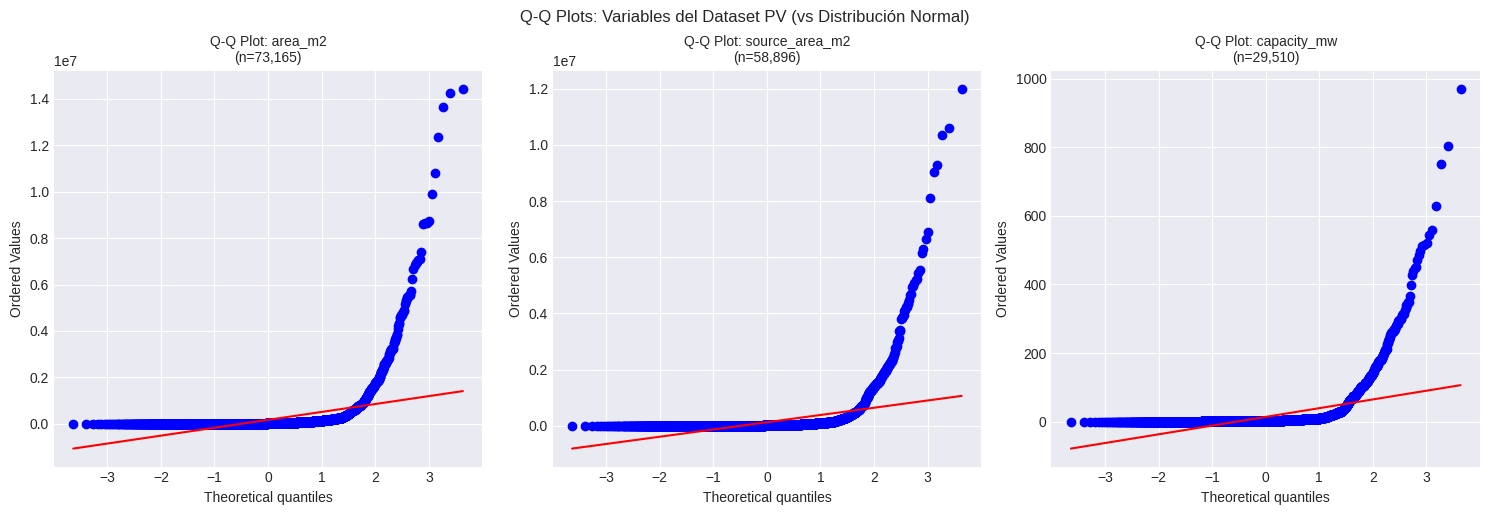

In [23]:
# Normality analysis for PV installation variables
print("📊 Análisis de Normalidad: Variables del Dataset PV")
print("=" * 80)

pv_analysis_vars = ['area_m2', 'source_area_m2', 'capacity_mw']

# First, check data availability
print("\n📋 Disponibilidad de datos:")
for var in pv_analysis_vars:
    if var in pv_census_df.columns:
        non_null = pv_census_df[var].notna().sum()
        pct = non_null / len(pv_census_df) * 100
        print(f"   {var}: {non_null:,} valores válidos ({pct:.1f}%)")
    else:
        print(f"   {var}: ⚠️ No disponible en el dataset")

# Q-Q Plots for PV variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, var in enumerate(pv_analysis_vars):
    ax = axes[idx]
    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        if len(data) > 0:
            # Use sample for visualization (max 5000 points for Q-Q plot)
            sample_data = data.sample(n=min(5000, len(data)), random_state=42)
            stats.probplot(sample_data, dist="norm", plot=ax)
            ax.set_title(f'Q-Q Plot: {var}\n(n={len(data):,})', fontsize=10)
        else:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{var}: Sin datos')
    else:
        ax.text(0.5, 0.5, 'Variable no disponible', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{var}')

plt.tight_layout()
plt.suptitle('Q-Q Plots: Variables del Dataset PV (vs Distribución Normal)', y=1.02, fontsize=12)
plt.show()

In [24]:
# Statistical normality tests for PV variables
print("\n📊 Pruebas de Normalidad para Variables PV")
print("=" * 80)
print(f"{'Variable':<20} {'N':<12} {'Shapiro-Wilk p':<18} {'K-S p':<18} {'Normal?':<10} {'Recomendación'}")
print("-" * 100)

pv_normality_results = []

for var in pv_analysis_vars:
    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        n = len(data)

        if n > 0:
            # Shapiro-Wilk (sample for large datasets)
            sample_size = min(5000, n)
            sample = data.sample(n=sample_size, random_state=42)
            shapiro_stat, shapiro_p = stats.shapiro(sample)

            # K-S test (standardize first)
            standardized = (data - data.mean()) / data.std()
            ks_stat, ks_p = stats.kstest(standardized, 'norm')

            is_normal = (shapiro_p > 0.05 and ks_p > 0.05)
            recommendation = "Paramétrica" if is_normal else "No paramétrica o transformar"

            pv_normality_results.append({
                'variable': var,
                'n': n,
                'shapiro_p': shapiro_p,
                'ks_p': ks_p,
                'is_normal': is_normal
            })

            print(f"{var:<20} {n:<12,} p={shapiro_p:.2e}  {'✓' if shapiro_p > 0.05 else '✗'}    p={ks_p:.2e}  {'✓' if ks_p > 0.05 else '✗'}    {'Sí' if is_normal else 'No':<10} {recommendation}")
        else:
            print(f"{var:<20} {'N/A':<12} {'Sin datos':<18} {'Sin datos':<18} {'N/A':<10}")
    else:
        print(f"{var:<20} {'N/A':<12} {'No disponible':<18} {'No disponible':<18} {'N/A':<10}")

print("-" * 100)
print("\n💡 Interpretación:")
print("   - Las variables de área y capacidad típicamente siguen distribuciones log-normales o de cola pesada")
print("   - Para análisis paramétricos, considerar transformación logarítmica: log(x + 1)")
print("   - Para comparaciones de grupos, usar pruebas no paramétricas (Mann-Whitney U, Kruskal-Wallis)")


📊 Pruebas de Normalidad para Variables PV
Variable             N            Shapiro-Wilk p     K-S p              Normal?    Recomendación
----------------------------------------------------------------------------------------------------
area_m2              73,165       p=2.56e-90  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar
source_area_m2       58,896       p=2.03e-90  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar
capacity_mw          29,510       p=2.09e-88  ✗    p=0.00e+00  ✗    No         No paramétrica o transformar
----------------------------------------------------------------------------------------------------

💡 Interpretación:
   - Las variables de área y capacidad típicamente siguen distribuciones log-normales o de cola pesada
   - Para análisis paramétricos, considerar transformación logarítmica: log(x + 1)
   - Para comparaciones de grupos, usar pruebas no paramétricas (Mann-Whitney U, Kruskal-Wallis)


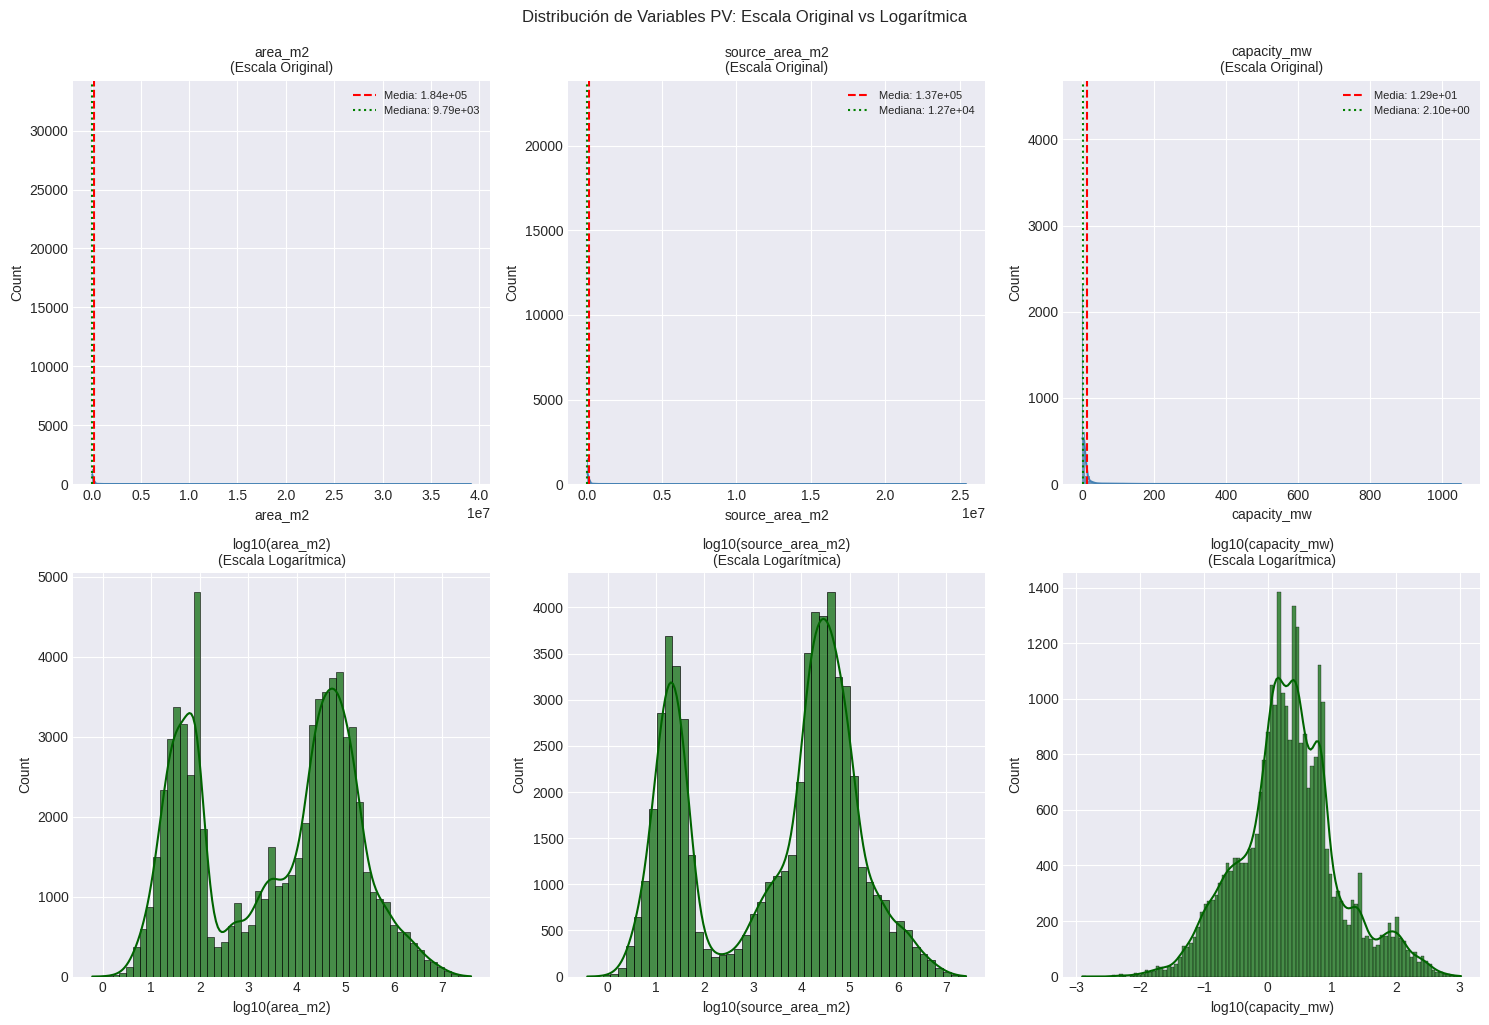


📊 Estadísticas descriptivas de variables PV:
            area_m2  source_area_m2   capacity_mw
count  7.316500e+04    5.889600e+04  29510.000000
mean   1.843910e+05    1.369410e+05     12.868979
std    8.962992e+05    6.339311e+05     44.217312
min    0.000000e+00    3.806191e-01      0.001250
25%    7.321550e+01    3.501215e+01      0.783000
50%    9.786646e+03    1.269500e+04      2.100000
75%    7.037709e+04    5.043949e+04      6.100000
max    3.913685e+07    2.542555e+07   1051.703000


In [25]:
# Distribution histograms with log scale option
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, var in enumerate(pv_analysis_vars):
    # Top row: Original scale
    ax_orig = axes[0, idx]
    # Bottom row: Log scale
    ax_log = axes[1, idx]

    if var in pv_census_df.columns:
        data = pv_census_df[var].dropna()
        data_positive = data[data > 0]  # Log requires positive values

        if len(data) > 0:
            # Original scale histogram
            sns.histplot(data, kde=True, ax=ax_orig, color='steelblue', alpha=0.7)
            ax_orig.set_title(f'{var}\n(Escala Original)', fontsize=10)
            ax_orig.axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.2e}')
            ax_orig.axvline(data.median(), color='green', linestyle=':', label=f'Mediana: {data.median():.2e}')
            ax_orig.legend(fontsize=8)

            # Log scale histogram (for positive values)
            if len(data_positive) > 0:
                log_data = np.log10(data_positive)
                sns.histplot(log_data, kde=True, ax=ax_log, color='darkgreen', alpha=0.7)
                ax_log.set_title(f'log10({var})\n(Escala Logarítmica)', fontsize=10)
                ax_log.set_xlabel(f'log10({var})')
            else:
                ax_log.text(0.5, 0.5, 'Sin valores positivos', ha='center', va='center', transform=ax_log.transAxes)
        else:
            ax_orig.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax_orig.transAxes)
            ax_log.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax_log.transAxes)
    else:
        ax_orig.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax_orig.transAxes)
        ax_log.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax_log.transAxes)

plt.tight_layout()
plt.suptitle('Distribución de Variables PV: Escala Original vs Logarítmica', y=1.02, fontsize=12)
plt.show()

print("\n📊 Estadísticas descriptivas de variables PV:")
pv_stats = pv_census_df[pv_analysis_vars].describe()
print(pv_stats.to_string())

### 3.1 Descarga de Variables del Censo para Todos los Census Tracts

Utilizamos la API del Censo de EEUU vía `censusdis` para obtener variables demográficas y socioeconómicas:

| Variable | Código | Descripción |
|----------|--------|-------------|
| total_population | B01003_001E | Población total |
| median_household_income | B19013_001E | Ingreso mediano del hogar |
| population_below_poverty | B17001_002E | Población bajo nivel de pobreza |
| median_home_value | B25077_001E | Valor mediano de vivienda |
| pct_unemployment | DP03_0009PE | % desempleo |
| pct_bachelors_or_higher | DP02_0068PE | % con bachillerato o más |
| pct_hispanic | DP05_0071PE | % población hispana |

In [26]:
# Define census variables to fetch
CENSUS_YEAR = 2022
ACS_DATASET = "acs/acs5"
ACS_PROFILE = "acs/acs5/profile"

# Detailed table variables
VARS_DETAILED = {
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income",
    "B17001_002E": "population_below_poverty",
    "B25077_001E": "median_home_value",
    "B25001_001E": "total_housing_units",  # For solar adoption rate calculation
}

# Profile variables (percentages)
VARS_PROFILE = {
    "DP03_0009PE": "pct_unemployment",
    "DP02_0068PE": "pct_bachelors_or_higher",
    "DP05_0071PE": "pct_hispanic",
}

# Get unique states from our PV dataset
pv_states = pv_census_df['STATE_FIPS'].unique().tolist()
print(f"📊 Estados con instalaciones FV en nuestro dataset: {len(pv_states)}")
print(f"   {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in pv_states]}")

# NOTE: Some territories (Guam=66, Virgin Islands=78) do not have ACS5 tract data
# Puerto Rico (72) does have ACS5 tract data
TERRITORIES_NO_ACS5 = {"66", "78"}  # GU, VI

📊 Estados con instalaciones FV en nuestro dataset: 54
   ['CA', 'AL', 'AR', 'AZ', 'CO', 'CT', 'DC', 'PA', 'DE', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'NE', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'RI', 'SC', 'TN', 'TX', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'SD', 'NH', 'UT', 'ME', 'ID', 'ND', 'AK', 'HI', '66', '78', 'PR']


In [27]:
# Fetch census data for all tracts in states with PV installations
print("📥 Descargando variables del Censo para todos los census tracts...")
print("   Esto puede tomar unos minutos dependiendo de la conexión...")
print(f"   ⚠️ Territorios sin datos ACS5: {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in TERRITORIES_NO_ACS5]}\n")

all_tracts_detailed = []
all_tracts_profile = []
skipped_territories = []

t1 = time.time()
for state_fips in pv_states:
    state_name = NAMES_FROM_IDS.get(state_fips, state_fips)

    # Skip territories without ACS5 tract data
    if state_fips in TERRITORIES_NO_ACS5:
        print(f"   ⏭️  Omitiendo {state_name} (sin datos ACS5 para tracts)")
        skipped_territories.append(state_fips)
        continue

    print(f"   Descargando datos para {state_name}...", end=" ")

    try:
        # Fetch detailed variables with geometry
        df_det = ced.download(
            ACS_DATASET,
            CENSUS_YEAR,
            ["NAME", "GEO_ID"] + list(VARS_DETAILED.keys()),
            state=state_fips,
            county="*",
            tract="*",
            with_geometry=True
        )

        # Fetch profile variables (no geometry needed)
        df_prof = ced.download(
            ACS_PROFILE,
            CENSUS_YEAR,
            list(VARS_PROFILE.keys()),
            state=state_fips,
            county="*",
            tract="*",
            with_geometry=False
        )

        all_tracts_detailed.append(df_det)
        all_tracts_profile.append(df_prof)
        print(f"✓ ({len(df_det):,} tracts)")

    except Exception as e:
        print(f"✗ Error: {e}")
        skipped_territories.append(state_fips)

t2 = time.time()
print(f"\n✅ Descarga completada en {t2-t1:.1f} segundos.")
if skipped_territories:
    print(f"⚠️  Territorios omitidos: {[ABBREVIATIONS_FROM_IDS.get(s, s) for s in skipped_territories]}")

📥 Descargando variables del Censo para todos los census tracts...
   Esto puede tomar unos minutos dependiendo de la conexión...
   ⚠️ Territorios sin datos ACS5: ['66', '78']

   Descargando datos para California... ✓ (9,129 tracts)
   Descargando datos para Alabama... ✓ (1,437 tracts)
   Descargando datos para Arkansas... ✓ (823 tracts)
   Descargando datos para Arizona... ✓ (1,765 tracts)
   Descargando datos para Colorado... ✓ (1,447 tracts)
   Descargando datos para Connecticut... ✓ (884 tracts)
   Descargando datos para District of Columbia... ✓ (206 tracts)
   Descargando datos para Pennsylvania... ✓ (3,446 tracts)
   Descargando datos para Delaware... ✓ (262 tracts)
   Descargando datos para Florida... ✓ (5,160 tracts)
   Descargando datos para Georgia... ✓ (2,796 tracts)
   Descargando datos para Iowa... ✓ (896 tracts)
   Descargando datos para Illinois... ✓ (3,265 tracts)
   Descargando datos para Indiana... ✓ (1,696 tracts)
   Descargando datos para Kansas... ✓ (829 tracts)


In [28]:
# Combine all states into single dataframes
census_detailed_gdf = gpd.GeoDataFrame(pd.concat(all_tracts_detailed, ignore_index=True))
census_profile_df = pd.concat(all_tracts_profile, ignore_index=True)

# Merge detailed and profile data
census_all_tracts = census_detailed_gdf.merge(
    census_profile_df,
    on=["STATE", "COUNTY", "TRACT"],
    how="left"
)

# Rename columns to human-friendly English names
rename_map = {**VARS_DETAILED, **VARS_PROFILE}
census_all_tracts = census_all_tracts.rename(columns=rename_map)

# Create TRACT_GEOID for joining with PV data (STATE + COUNTY + TRACT)
census_all_tracts['TRACT_GEOID'] = census_all_tracts['STATE'] + census_all_tracts['COUNTY'] + census_all_tracts['TRACT']

print(f"📊 Total de census tracts descargados: {len(census_all_tracts):,}")
print(f"   Columnas: {list(census_all_tracts.columns)}")
display(census_all_tracts.head())

📊 Total de census tracts descargados: 85,396
   Columnas: ['STATE', 'COUNTY', 'TRACT', 'NAME', 'GEO_ID', 'total_population', 'median_household_income', 'population_below_poverty', 'median_home_value', 'total_housing_units', 'geometry', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic', 'TRACT_GEOID']


,STATE,COUNTY,TRACT,NAME,GEO_ID,total_population,median_household_income,population_below_poverty,median_home_value,total_housing_units,geometry,pct_unemployment,pct_bachelors_or_higher,pct_hispanic,TRACT_GEOID
0,06,001,400100,Census Tract 4001; Alameda County; California,1400000US06001400100,3269,234236.0,142,1635300.0,1496,"POLYGON ((-122.24691 37.88536, -122.24197 37.8...",5.0,84.1,2.4,06001400100
1,06,001,400200,Census Tract 4002; Alameda County; California,1400000US06001400200,2147,225500.0,161,1939900.0,913,"POLYGON ((-122.25742 37.8431, -122.2562 37.844...",6.1,86.4,6.7,06001400200
2,06,001,400300,Census Tract 4003; Alameda County; California,1400000US06001400300,5619,164000.0,396,1741100.0,2851,"POLYGON ((-122.26534 37.83846, -122.26459 37.8...",7.2,80.0,10.4,06001400300
3,06,001,400400,Census Tract 4004; Alameda County; California,1400000US06001400400,4278,158836.0,419,1406500.0,1975,"POLYGON ((-122.2618 37.84179, -122.2613 37.845...",0.2,75.9,6.0,06001400400
4,06,001,400500,Census Tract 4005; Alameda County; California,1400000US06001400500,3949,95078.0,409,1156500.0,1820,"POLYGON ((-122.26941 37.84811, -122.26896 37.8...",8.0,68.6,11.9,06001400500


### 3.2 Creación del DataFrame de Análisis

Unimos los datos del Censo con nuestro conteo de instalaciones FV por tract para crear:
- `n_solar`: Cantidad de instalaciones FV en el tract
- `area_km2`: Área del tract en km²
- `solar_density`: Densidad de instalaciones (n_solar / area_km2) - útil para análisis espacial
- `solar_adoption_rate`: Instalaciones por cada 1,000 unidades de vivienda - **mejor métrica para comparaciones**
- `solar_capacity_per_capita`: Capacidad MW por cada 1,000 residentes - mide intensidad de generación
- `log_solar_count`: Transformación logarítmica log(n_solar + 1) - ver nota abajo
- `has_solar`: Variable binaria (1 si tiene instalaciones, 0 si no)

> **Nota**: `solar_adoption_rate` es preferible a `solar_density` porque normaliza por oportunidad
> (unidades de vivienda) en lugar de área, haciéndola comparable entre contextos urbanos y rurales.

---

#### 📐 Sobre la Transformación Logarítmica (`log_solar_count`)

La transformación `log(n + 1)` (también llamada *log1p*) es una técnica estadística común para:

1. **Manejar ceros**: A diferencia de `log(n)`, `log(n + 1)` está definida para n=0 (resulta en 0)

2. **Reducir asimetría (skewness)**: Las distribuciones de conteos suelen tener "cola derecha"
   (muchos valores bajos, pocos valores muy altos). La transformación logarítmica comprime
   los valores altos y expande los bajos, aproximando a una distribución más simétrica.

3. **Estabilizar varianza**: En datos de conteo, la varianza suele aumentar con la media.
   La transformación log estabiliza esta varianza (homocedasticidad). [???]

4. **Interpretación multiplicativa**: En regresión, coeficientes con log se interpretan como
   cambios porcentuales: "un aumento de 1 unidad en X se asocia con un aumento de β% en el conteo"

**Cuándo usarla:**
- En regresiones lineales donde la variable dependiente es un conteo
- Cuando los residuos muestran heterocedasticidad [?????]
- Para visualizaciones donde los valores extremos comprimen el resto

**Referencias:**
- [Log Transformation in Statistics](https://en.wikipedia.org/wiki/Data_transformation_(statistics)#Log_transformation)
- [When to Use Log Transforms](https://stats.stackexchange.com/questions/18844/when-and-why-should-you-take-the-log-of-a-distribution)

In [29]:
# Count solar installations per tract and aggregate capacity
solar_counts = pv_census_df.groupby('TRACT_GEOID').size().reset_index(name='n_solar')

# Aggregate total capacity per tract (if capacity_mw is available)
if 'capacity_mw' in pv_census_df.columns:
    solar_capacity = pv_census_df.groupby('TRACT_GEOID')['capacity_mw'].sum().reset_index(name='total_capacity_mw')
    solar_counts = solar_counts.merge(solar_capacity, on='TRACT_GEOID', how='left')
    solar_counts['total_capacity_mw'] = solar_counts['total_capacity_mw'].fillna(0)
    print(f"📊 Tracts con instalaciones FV: {len(solar_counts):,}")
    print(f"   Capacidad total agregada: {solar_counts['total_capacity_mw'].sum():,.2f} MW")
else:
    solar_counts['total_capacity_mw'] = 0
    print(f"📊 Tracts con instalaciones FV: {len(solar_counts):,}")
    print(f"   ⚠️ capacity_mw no disponible - solar_capacity_per_capita será 0")

# Merge with census data (left join to keep all tracts)
analysis_df = census_all_tracts.merge(
    solar_counts,
    on='TRACT_GEOID',
    how='left'
)

# Fill NaN for tracts without solar installations
analysis_df['n_solar'] = analysis_df['n_solar'].fillna(0).astype(int)

# Calculate area in km² using appropriate projection (Albers Equal Area for CONUS)
# First ensure we have geometry and proper CRS
analysis_gdf = gpd.GeoDataFrame(analysis_df, geometry='geometry', crs='EPSG:4269')
analysis_gdf = analysis_gdf.to_crs(epsg=5070)  # NAD83 / Conus Albers for area calculation

# Calculate area; 1km2 = 1,000,000 m2
analysis_gdf['area_km2'] = analysis_gdf.geometry.area / 1_000_000

# Calculate solar density and binary indicator
analysis_gdf['solar_density'] = analysis_gdf['n_solar'] / analysis_gdf['area_km2']
analysis_gdf['has_solar'] = (analysis_gdf['n_solar'] > 0).astype(int)

# Calculate solar adoption rate (installations per 1,000 housing units)
# This is a better metric than solar_density because it normalizes by opportunity (housing stock)
# rather than area, making it comparable across urban and rural contexts
analysis_gdf['solar_adoption_rate'] = np.where(
    analysis_gdf['total_housing_units'] > 0,
    (analysis_gdf['n_solar'] / analysis_gdf['total_housing_units']) * 1000,
    0
)

# Calculate solar capacity per capita (MW per 1,000 residents)
# This captures both the quantity AND size of installations
# Useful for understanding total generation potential relative to population
if 'total_capacity_mw' in analysis_gdf.columns:
    analysis_gdf['solar_capacity_per_capita'] = np.where(
        analysis_gdf['total_population'] > 0,
        (analysis_gdf['total_capacity_mw'] / analysis_gdf['total_population']) * 1000,
        0
    )
else:
    analysis_gdf['solar_capacity_per_capita'] = 0

# Log-transformed solar count: log(n + 1)
# This transformation:
# - Handles zeros (log(0+1) = 0)
# - Reduces skewness in count distributions
# - Stabilizes variance for regression analysis
# - Enables multiplicative interpretation in models
analysis_gdf['log_solar_count'] = np.log1p(analysis_gdf['n_solar'])

# Convert back to WGS84 for visualization
analysis_gdf = analysis_gdf.to_crs(epsg=4326)

print(f"\n📊 DataFrame de Análisis Final:")
print(f"   Total tracts: {len(analysis_gdf):,}")
print(f"   Tracts CON instalaciones FV: {analysis_gdf['has_solar'].sum():,}")
print(f"   Tracts SIN instalaciones FV: {(~analysis_gdf['has_solar'].astype(bool)).sum():,}")

# Show summary statistics for all derived variables
print("\n📈 Estadísticas de variables derivadas:")
derived_vars = ['n_solar', 'log_solar_count', 'area_km2', 'solar_density', 'solar_adoption_rate', 'solar_capacity_per_capita']
derived_stats = analysis_gdf[derived_vars].describe()
print(derived_stats.to_string())

# Check for potential issues with solar_density (very small values)
print("\n🔍 Diagnóstico de métricas para tracts CON instalaciones FV:")
with_solar = analysis_gdf[analysis_gdf['has_solar'] == 1]
print(f"   solar_density:           {with_solar['solar_density'].min():.2e} to {with_solar['solar_density'].max():.4f} (inst/km²)")
print(f"   solar_adoption_rate:     {with_solar['solar_adoption_rate'].min():.2f} to {with_solar['solar_adoption_rate'].max():.2f} (per 1,000 housing units)")
print(f"   solar_capacity_per_capita: {with_solar['solar_capacity_per_capita'].min():.4f} to {with_solar['solar_capacity_per_capita'].max():.4f} (MW per 1,000 pop)")
print(f"   log_solar_count:         {with_solar['log_solar_count'].min():.4f} to {with_solar['log_solar_count'].max():.4f}")
print(f"\n   Medianas (tracts con FV):")
print(f"   - solar_adoption_rate:     {with_solar['solar_adoption_rate'].median():.2f} per 1,000 units")
print(f"   - solar_capacity_per_capita: {with_solar['solar_capacity_per_capita'].median():.4f} MW per 1,000 pop")
print(f"   - log_solar_count:         {with_solar['log_solar_count'].median():.4f}")

# Show summary statistics with better formatting
display(analysis_gdf[['total_population', 'median_household_income', 'population_below_poverty',
                       'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher',
                       'pct_hispanic', 'n_solar', 'solar_adoption_rate', 'solar_capacity_per_capita', 'log_solar_count']].describe())

📊 Tracts con instalaciones FV: 10,754
   Capacidad total agregada: 379,763.58 MW

📊 DataFrame de Análisis Final:
   Total tracts: 85,396
   Tracts CON instalaciones FV: 10,595
   Tracts SIN instalaciones FV: 74,801

📈 Estadísticas de variables derivadas:
            n_solar  log_solar_count       area_km2  solar_density  solar_adoption_rate  solar_capacity_per_capita
count  85396.000000     85396.000000   85062.000000   85062.000000         85396.000000               11382.000000
mean       0.850813         0.176552     109.945551       0.134281             0.806166                  14.099354
std       14.264498         0.552100    1323.085165       2.273619            19.748943                 167.727491
min        0.000000         0.000000       0.004755       0.000000             0.000000                   0.000000
25%        0.000000         0.000000       1.760599       0.000000             0.000000                   0.006866
50%        0.000000         0.000000       4.750183    

,total_population,median_household_income,population_below_poverty,median_home_value,total_housing_units,pct_unemployment,pct_bachelors_or_higher,pct_hispanic,n_solar,solar_adoption_rate,solar_capacity_per_capita,log_solar_count
count,85396.000000,83815.000000,85396.000000,8.219500e+04,85396.000000,84386.000000,83596.000000,84539.000000,85396.000000,85396.000000,11382.000000,85396.000000
mean,3915.522683,80115.764493,490.537543,3.468469e+05,1668.775376,5.731656,32.966301,11.242792,0.850813,0.806166,14.099354,0.176552
std,1744.882915,39631.407620,436.489525,2.937258e+05,706.048682,4.773613,19.910601,14.180431,14.264498,19.748943,167.727491,0.552100
min,0.000000,2499.000000,0.000000,9.999000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2700.000000,53139.500000,191.000000,1.602000e+05,1195.000000,2.600000,17.400000,2.000000,0.000000,0.000000,0.006866,0.000000
50%,3748.000000,71528.000000,370.000000,2.568000e+05,1608.000000,4.600000,28.300000,5.600000,0.000000,0.000000,0.380422,0.000000
75%,4936.000000,98059.500000,658.000000,4.312000e+05,2077.000000,7.500000,45.400000,14.300000,0.000000,0.000000,2.372306,0.000000
max,38907.000000,250001.000000,5760.000000,2.000001e+06,12980.000000,100.000000,100.000000,100.000000,3291.000000,3000.000000,12193.559700,8.099251


In [30]:
# Handle missing values - drop rows with missing census data for analysis
# Note: Census API returns -666666666 for missing/suppressed data
CENSUS_MISSING_VALUE = -666666666

analysis_vars = ['total_population', 'median_household_income', 'population_below_poverty',
                 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic']

print("📊 Valores faltantes en variables del Censo:")
for var in analysis_vars:
    missing_count = ((analysis_gdf[var].isna()) | (analysis_gdf[var] == CENSUS_MISSING_VALUE)).sum()
    pct = missing_count / len(analysis_gdf) * 100
    print(f"   {var}: {missing_count:,} ({pct:.2f}%)")

# Replace census missing values with NaN
for var in analysis_vars:
    analysis_gdf.loc[analysis_gdf[var] == CENSUS_MISSING_VALUE, var] = np.nan

# Create clean analysis dataset (drop rows with any missing values in analysis variables)
analysis_clean = analysis_gdf.dropna(subset=analysis_vars).copy()
print(f"\n✅ Dataset limpio para análisis: {len(analysis_clean):,} tracts")
print(f"   Eliminados por datos faltantes: {len(analysis_gdf) - len(analysis_clean):,}")

📊 Valores faltantes en variables del Censo:
   total_population: 0 (0.00%)
   median_household_income: 1,581 (1.85%)
   population_below_poverty: 0 (0.00%)
   median_home_value: 3,201 (3.75%)
   total_housing_units: 0 (0.00%)
   pct_unemployment: 1,010 (1.18%)
   pct_bachelors_or_higher: 1,800 (2.11%)
   pct_hispanic: 857 (1.00%)

✅ Dataset limpio para análisis: 81,052 tracts
   Eliminados por datos faltantes: 4,344


### 3.3 Visualización de Distribuciones y Correlaciones

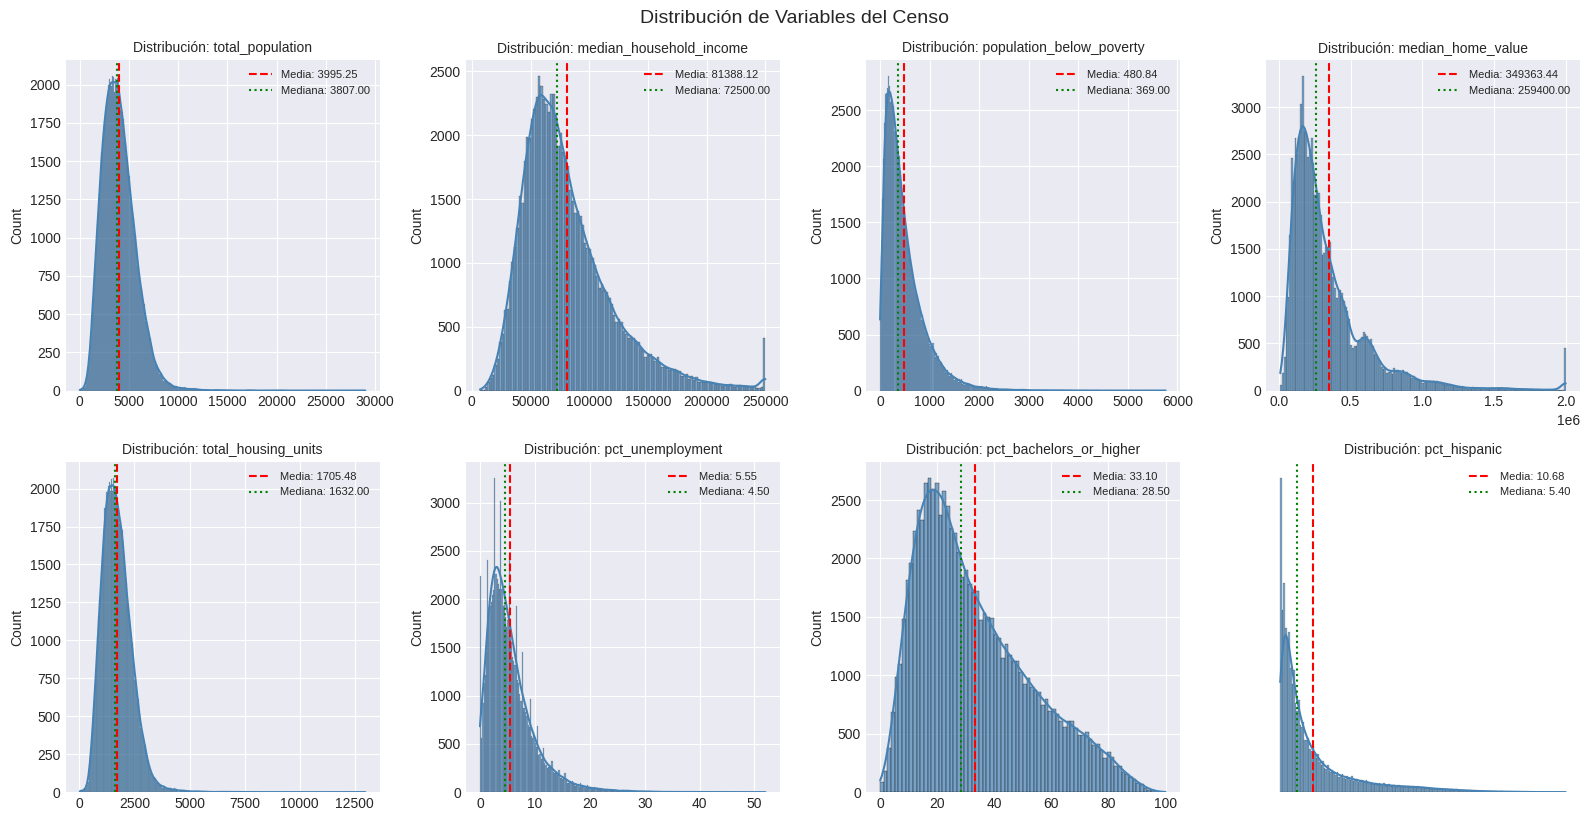

In [31]:
# Distribution plots for key variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(analysis_vars):
    ax = axes[idx]
    data = analysis_clean[var].dropna()

    sns.histplot(data, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'Distribución: {var}', fontsize=10)
    ax.set_xlabel('')

    # Add mean and median lines
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle=':', label=f'Mediana: {data.median():.2f}')
    ax.legend(fontsize=8)

# Remove empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Distribución de Variables del Censo', y=1.02, fontsize=14)
plt.show()

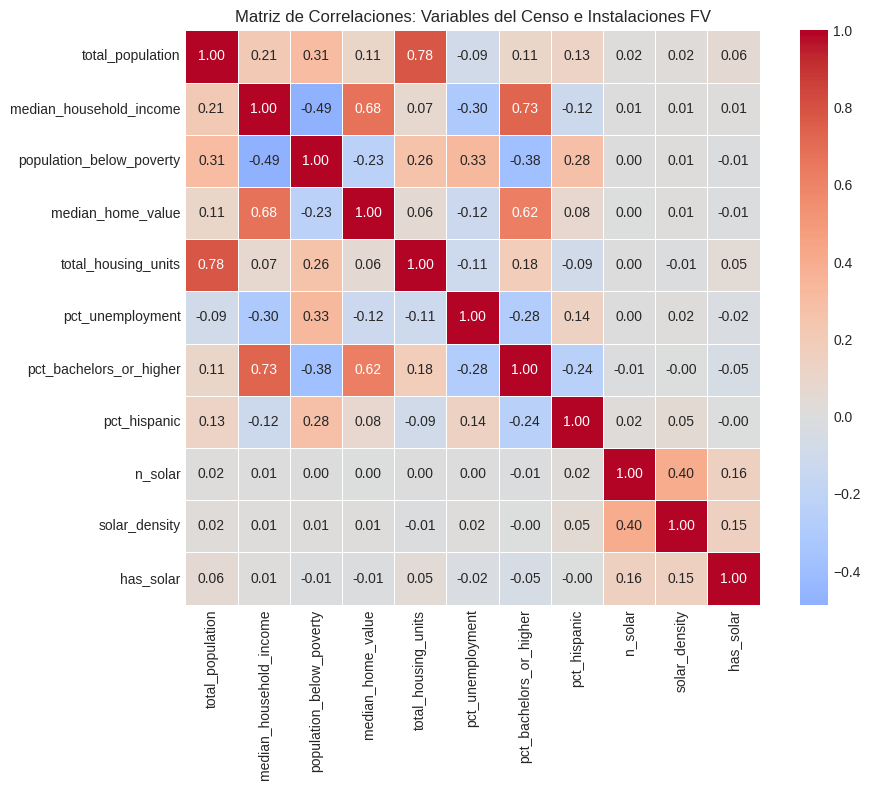

In [32]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr_vars = analysis_vars + ['n_solar', 'solar_density', 'has_solar']
corr_matrix = analysis_clean[corr_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Matriz de Correlaciones: Variables del Censo e Instalaciones FV')
plt.tight_layout()
plt.show()

### 3.4 Pruebas de Normalidad

Antes de seleccionar las pruebas estadísticas apropiadas, debemos verificar si nuestras variables siguen una distribución normal. Utilizamos:

1. **Q-Q Plots**: Visualización gráfica
2. **Shapiro-Wilk Test**: Prueba estadística (mejor para n < 5000)
3. **Kolmogorov-Smirnov Test**: Prueba estadística (para muestras grandes)

**Interpretación de p-value:**
- p > 0.05: No rechazamos H₀ → Los datos podrían ser normales
- p ≤ 0.05: Rechazamos H₀ → Los datos NO son normales

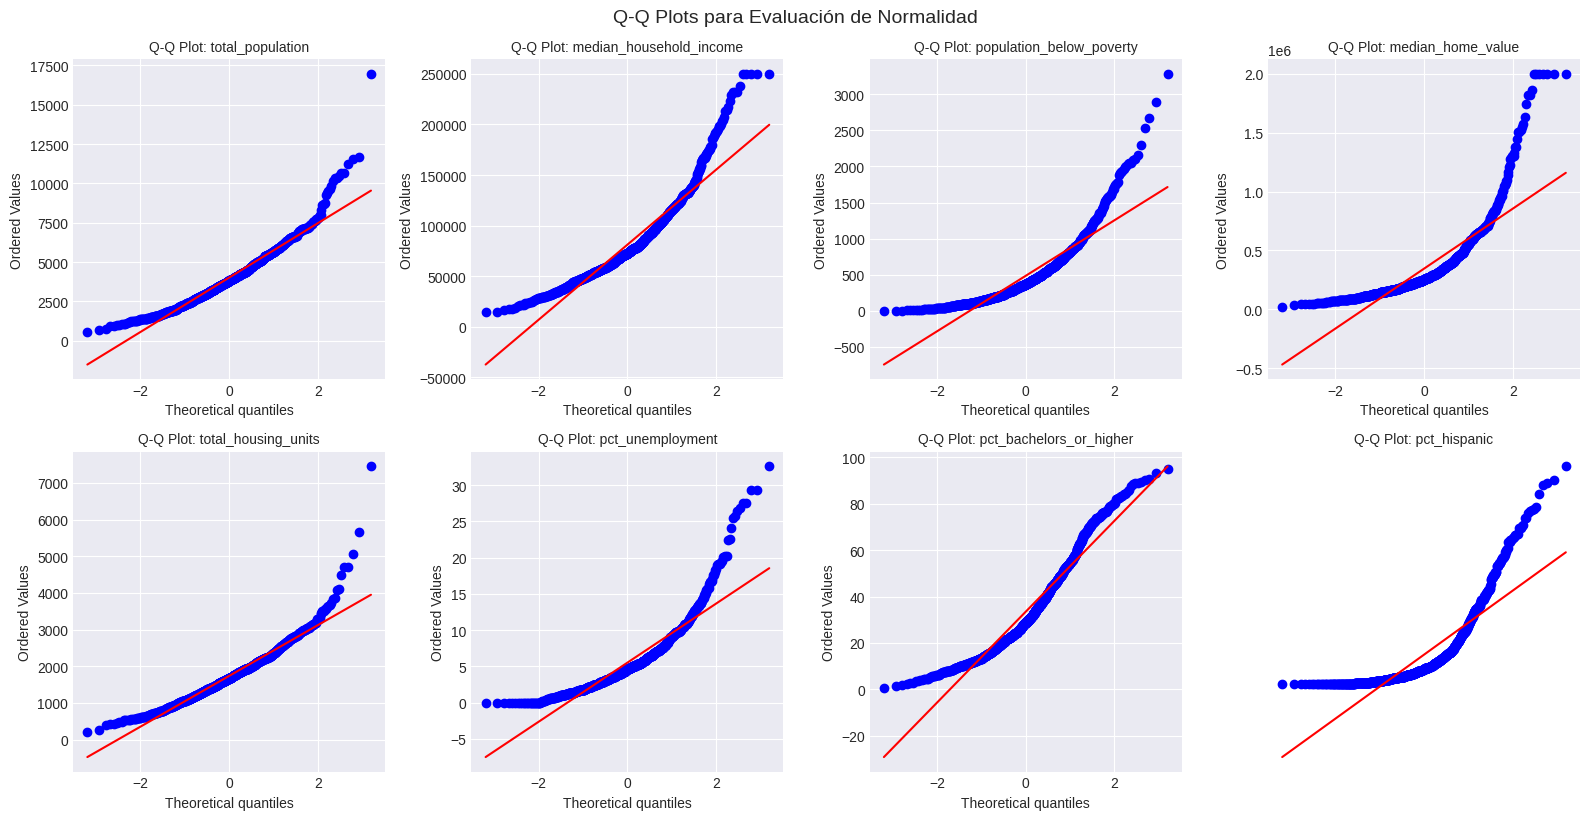

In [33]:
# Q-Q Plots for normality assessment
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(analysis_vars):
    ax = axes[idx]
    data = analysis_clean[var].dropna()

    # Use a sample if data is too large for visualization
    sample_data = data.sample(n=min(1000, len(data)), random_state=42)

    stats.probplot(sample_data, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {var}', fontsize=10)

axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Q-Q Plots para Evaluación de Normalidad', y=1.02, fontsize=14)
plt.show()

In [34]:
# Statistical normality tests
print("📊 Pruebas de Normalidad para Variables del Censo")
print("=" * 80)
print(f"{'Variable':<30} {'Shapiro-Wilk':<20} {'Kolmogorov-Smirnov':<20} {'Normal?'}")
print("-" * 80)

normality_results = []

for var in analysis_vars:
    data = analysis_clean[var].dropna()

    # Shapiro-Wilk test (use sample for large datasets)
    sample_size = min(5000, len(data))
    sample = data.sample(n=sample_size, random_state=42)
    shapiro_stat, shapiro_p = stats.shapiro(sample)

    # Kolmogorov-Smirnov test
    # Standardize data for K-S test against standard normal
    standardized = (data - data.mean()) / data.std()
    ks_stat, ks_p = stats.kstest(standardized, 'norm')

    is_normal = "Sí" if (shapiro_p > 0.05 and ks_p > 0.05) else "No"

    normality_results.append({
        'variable': var,
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'ks_stat': ks_stat,
        'ks_p': ks_p,
        'is_normal': is_normal == "Sí"
    })

    print(f"{var:<30} p={shapiro_p:.4f}  {'✓' if shapiro_p > 0.05 else '✗'}     p={ks_p:.4f}  {'✓' if ks_p > 0.05 else '✗'}      {is_normal}")

print("-" * 80)
print("Nota: ✓ indica p > 0.05 (no se rechaza normalidad), ✗ indica p ≤ 0.05 (se rechaza normalidad)")

normality_df = pd.DataFrame(normality_results)

📊 Pruebas de Normalidad para Variables del Censo
Variable                       Shapiro-Wilk         Kolmogorov-Smirnov   Normal?
--------------------------------------------------------------------------------
total_population               p=0.0000  ✗     p=0.0000  ✗      No
median_household_income        p=0.0000  ✗     p=0.0000  ✗      No
population_below_poverty       p=0.0000  ✗     p=0.0000  ✗      No
median_home_value              p=0.0000  ✗     p=0.0000  ✗      No
total_housing_units            p=0.0000  ✗     p=0.0000  ✗      No
pct_unemployment               p=0.0000  ✗     p=0.0000  ✗      No
pct_bachelors_or_higher        p=0.0000  ✗     p=0.0000  ✗      No
pct_hispanic                   p=0.0000  ✗     p=0.0000  ✗      No
--------------------------------------------------------------------------------
Nota: ✓ indica p > 0.05 (no se rechaza normalidad), ✗ indica p ≤ 0.05 (se rechaza normalidad)


### 3.5 Análisis de Poder Estadístico

El análisis de poder nos ayuda a determinar si tenemos suficientes observaciones para detectar efectos estadísticamente significativos.

**Conceptos clave:**
- **Effect Size (Cohen's d)**: Magnitud del efecto (pequeño=0.2, mediano=0.5, grande=0.8)
- **Alpha (α)**: Probabilidad de error Tipo I (falso positivo) - típicamente 0.05
- **Power (1-β)**: Probabilidad de detectar un efecto verdadero - típicamente 0.80
- **Sample Size (n)**: Número de observaciones necesarias

In [35]:
# Power Analysis
print("📊 Análisis de Poder Estadístico")
print("=" * 60)

# Get sample sizes for our two groups
n_with_solar = analysis_clean['has_solar'].sum()
n_without_solar = len(analysis_clean) - n_with_solar
print(f"\nTamaños de muestra actuales:")
print(f"   Tracts CON instalaciones FV (n₁): {n_with_solar:,}")
print(f"   Tracts SIN instalaciones FV (n₂): {n_without_solar:,}")
print(f"   Ratio n₂/n₁: {n_without_solar/n_with_solar:.2f}")

# Calculate required sample sizes for different effect sizes
effect_sizes = [0.2, 0.5, 0.8]
alpha = 0.05
power = 0.80

print(f"\n📐 Tamaño de muestra requerido por grupo (α={alpha}, power={power}):")
print("-" * 60)
for es in effect_sizes:
    required_n = smp.tt_ind_solve_power(
        effect_size=es,
        nobs1=None,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative='two-sided'
    )
    size_label = "pequeño" if es == 0.2 else ("mediano" if es == 0.5 else "grande")
    meets_req = "✓" if min(n_with_solar, n_without_solar) >= required_n else "✗"
    print(f"   Effect size {es} ({size_label}): n = {round(required_n):,} por grupo {meets_req}")

# Calculate actual power with our sample sizes
print(f"\n📈 Poder estadístico con nuestros tamaños de muestra actuales:")
print("-" * 60)
for es in effect_sizes:
    actual_power = smp.tt_ind_solve_power(
        effect_size=es,
        nobs1=n_with_solar,
        alpha=alpha,
        power=None,
        ratio=n_without_solar/n_with_solar,
        alternative='two-sided'
    )
    size_label = "pequeño" if es == 0.2 else ("mediano" if es == 0.5 else "grande")
    print(f"   Effect size {es} ({size_label}): power = {actual_power:.4f} ({actual_power*100:.1f}%)")

📊 Análisis de Poder Estadístico

Tamaños de muestra actuales:
   Tracts CON instalaciones FV (n₁): 10,162
   Tracts SIN instalaciones FV (n₂): 70,890
   Ratio n₂/n₁: 6.98

📐 Tamaño de muestra requerido por grupo (α=0.05, power=0.8):
------------------------------------------------------------
   Effect size 0.2 (pequeño): n = 393 por grupo ✓
   Effect size 0.5 (mediano): n = 64 por grupo ✓
   Effect size 0.8 (grande): n = 26 por grupo ✓

📈 Poder estadístico con nuestros tamaños de muestra actuales:
------------------------------------------------------------
   Effect size 0.2 (pequeño): power = nan (nan%)
   Effect size 0.5 (mediano): power = 1.0000 (100.0%)
   Effect size 0.8 (grande): power = 1.0000 (100.0%)


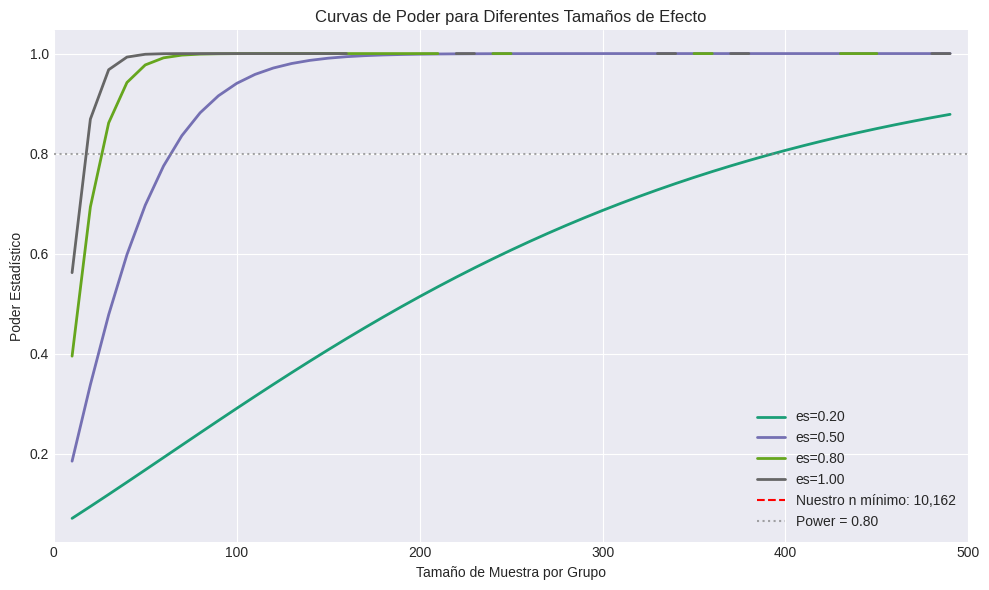


💡 Interpretación:
   Con nuestros tamaños de muestra, tenemos poder estadístico suficiente
   para detectar efectos pequeños (d=0.2) con alta confiabilidad.


In [36]:
# Power curves visualization
fig, ax = plt.subplots(figsize=(10, 6))

effect_sizes_range = np.array([0.2, 0.5, 0.8, 1.0])
sample_sizes_range = np.arange(10, 500, 10)

power_obj = smp.TTestIndPower()
power_obj.plot_power(dep_var='nobs', nobs=sample_sizes_range, effect_size=effect_sizes_range, ax=ax)

# Add vertical line for our smallest group
ax.axvline(x=min(n_with_solar, n_without_solar), color='red', linestyle='--',
           label=f'Nuestro n mínimo: {min(n_with_solar, n_without_solar):,}')
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Power = 0.80')

ax.set_xlabel("Tamaño de Muestra por Grupo")
ax.set_ylabel("Poder Estadístico")
ax.set_title("Curvas de Poder para Diferentes Tamaños de Efecto")
ax.legend(loc='lower right')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("   Con nuestros tamaños de muestra, tenemos poder estadístico suficiente")
print("   para detectar efectos pequeños (d=0.2) con alta confiabilidad.")

---

## 📈 4: Pruebas Estadísticas de Diferencias entre Grupos

Ahora que hemos verificado la normalidad (o falta de ella) de nuestras variables y confirmado que tenemos poder estadístico suficiente, realizamos las pruebas para determinar si existen diferencias significativas entre:

- **Grupo 1**: Census tracts CON instalaciones fotovoltaicas
- **Grupo 2**: Census tracts SIN instalaciones fotovoltaicas

### Selección de Prueba
- Si los datos son **normales**: t-test independiente
- Si los datos **NO son normales**: Mann-Whitney U (no paramétrica)

Basado en nuestros resultados de normalidad, utilizaremos **Mann-Whitney U** para la mayoría de las variables.

In [37]:
# Compare groups: with vs without solar installations
print("📊 Comparación de Grupos: Tracts con vs sin Instalaciones FV")
print("=" * 80)

# Split data into two groups
group_with_solar = analysis_clean[analysis_clean['has_solar'] == 1]
group_without_solar = analysis_clean[analysis_clean['has_solar'] == 0]

print(f"\nEstadísticas descriptivas por grupo:")
print("-" * 80)

comparison_results = []

for var in analysis_vars:
    data_with = group_with_solar[var].dropna()
    data_without = group_without_solar[var].dropna()

    # Calculate means and medians
    mean_with = data_with.mean()
    mean_without = data_without.mean()
    median_with = data_with.median()
    median_without = data_without.median()

    # Determine which test to use based on normality
    var_is_normal = normality_df[normality_df['variable'] == var]['is_normal'].values[0]

    if var_is_normal:
        # Use independent t-test
        stat, p_value = stats.ttest_ind(data_with, data_without)
        test_name = "t-test"
    else:
        # Use Mann-Whitney U test
        stat, p_value = stats.mannwhitneyu(data_with, data_without, alternative='two-sided')
        test_name = "Mann-Whitney U"

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(data_with)-1)*data_with.std()**2 + (len(data_without)-1)*data_without.std()**2) /
                         (len(data_with) + len(data_without) - 2))
    cohens_d = (mean_with - mean_without) / pooled_std if pooled_std > 0 else 0

    sig = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))

    comparison_results.append({
        'variable': var,
        'mean_with_solar': mean_with,
        'mean_without_solar': mean_without,
        'median_with_solar': median_with,
        'median_without_solar': median_without,
        'test': test_name,
        'statistic': stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'significant': p_value < 0.05
    })

# Display results as DataFrame
results_df = pd.DataFrame(comparison_results)
print("\n📋 Resultados de las Pruebas Estadísticas:")
display(results_df[['variable', 'mean_with_solar', 'mean_without_solar', 'test', 'p_value', 'cohens_d', 'significant']])

📊 Comparación de Grupos: Tracts con vs sin Instalaciones FV

Estadísticas descriptivas por grupo:
--------------------------------------------------------------------------------

📋 Resultados de las Pruebas Estadísticas:


,variable,mean_with_solar,mean_without_solar,test,p_value,cohens_d,significant
0,total_population,4264.737355,3956.618917,Mann-Whitney U,1.529037e-64,0.183227,True
1,median_household_income,82582.485731,81216.909155,Mann-Whitney U,4.003166e-13,0.034720,True
2,population_below_poverty,474.617103,481.734293,Mann-Whitney U,6.818789e-01,-0.017496,False
3,median_home_value,338106.449321,350977.116476,Mann-Whitney U,9.621040e-01,-0.043737,False
4,total_housing_units,1786.657154,1693.847581,Mann-Whitney U,7.248511e-43,0.137687,True
5,pct_unemployment,5.272840,5.591916,Mann-Whitney U,8.130445e-06,-0.072733,True
6,pct_bachelors_or_higher,30.600335,33.462407,Mann-Whitney U,1.023384e-33,-0.144960,True
7,pct_hispanic,10.554861,10.701411,Mann-Whitney U,8.086680e-01,-0.010885,False


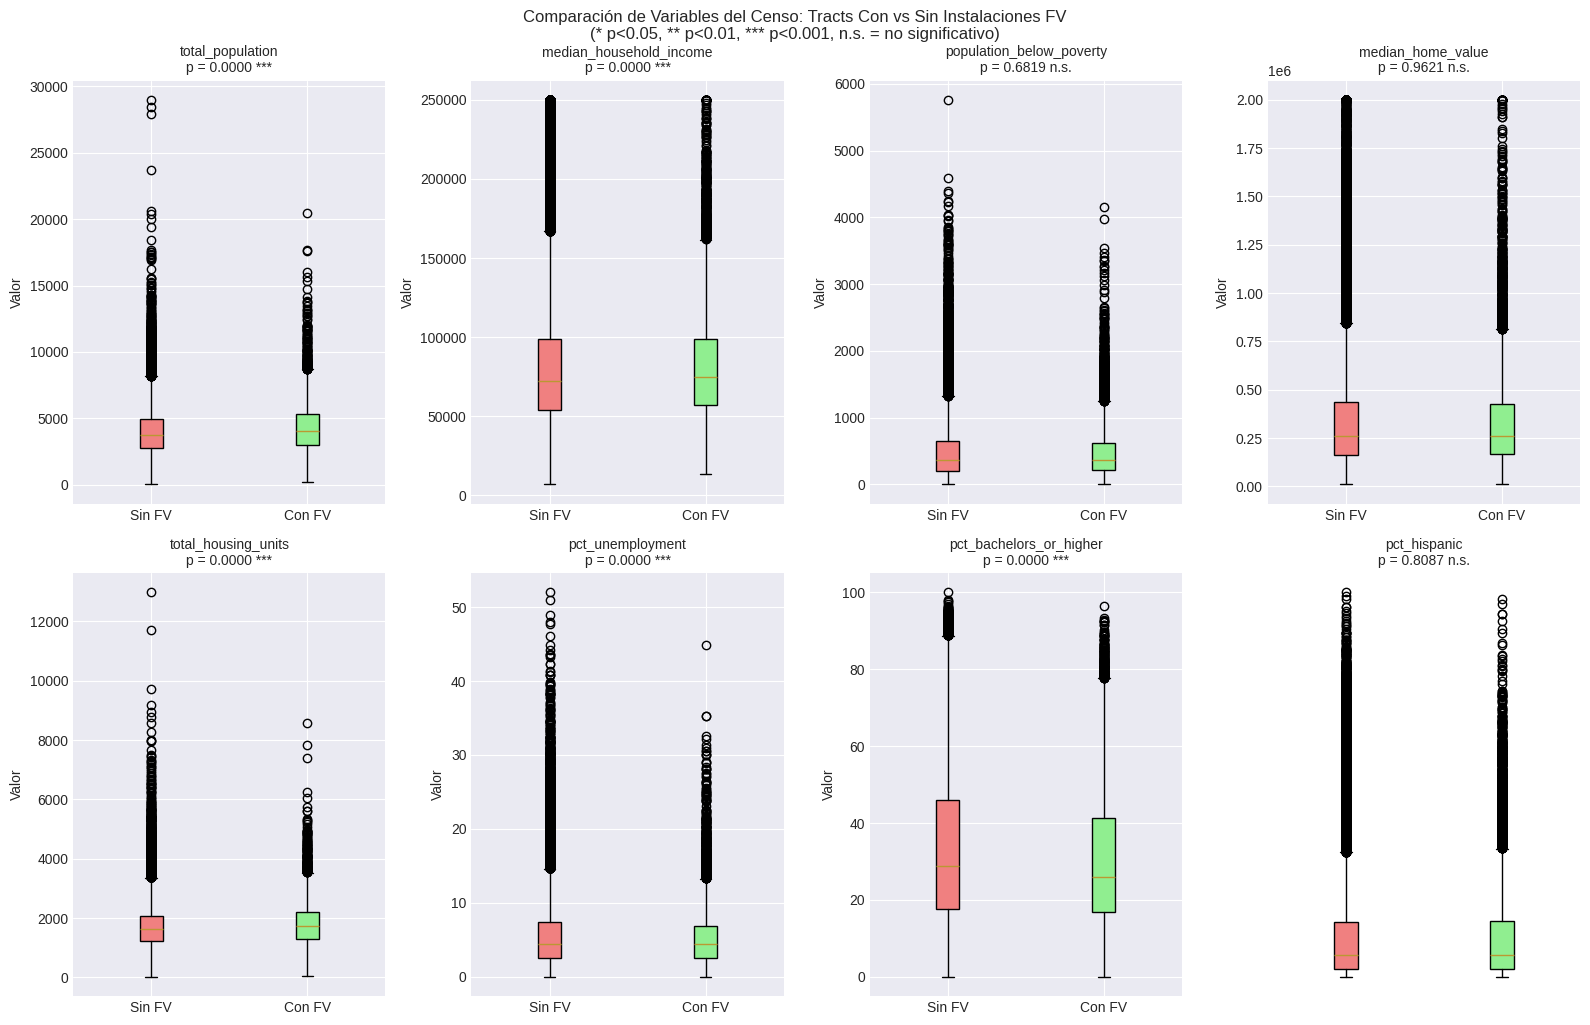

In [38]:
# Visualize group comparisons
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(analysis_vars):
    ax = axes[idx]

    # Prepare data for boxplot
    data_with = group_with_solar[var].dropna()
    data_without = group_without_solar[var].dropna()

    # Create boxplot
    box_data = [data_without, data_with]
    bp = ax.boxplot(box_data, tick_labels=['Sin FV', 'Con FV'], patch_artist=True)

    # Color the boxes
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')

    # Get p-value for title
    p_val = results_df[results_df['variable'] == var]['p_value'].values[0]
    sig_marker = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s."))

    ax.set_title(f'{var}\np = {p_val:.4f} {sig_marker}', fontsize=10)
    ax.set_ylabel('Valor')

axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Comparación de Variables del Censo: Tracts Con vs Sin Instalaciones FV\n(* p<0.05, ** p<0.01, *** p<0.001, n.s. = no significativo)',
             y=1.02, fontsize=12)
plt.show()

In [39]:
# Summary of significant differences
print("\n📊 Resumen de Diferencias Significativas (p < 0.05):")
print("=" * 60)

sig_results = results_df[results_df['significant']]
if len(sig_results) > 0:
    for _, row in sig_results.iterrows():
        direction = "mayor" if row['mean_with_solar'] > row['mean_without_solar'] else "menor"
        effect_size = "pequeño" if abs(row['cohens_d']) < 0.5 else ("mediano" if abs(row['cohens_d']) < 0.8 else "grande")
        print(f"\n   📍 {row['variable']}:")
        print(f"      - Los tracts CON instalaciones FV tienen un valor {direction}")
        print(f"      - Media con FV: {row['mean_with_solar']:.2f} vs sin FV: {row['mean_without_solar']:.2f}")
        print(f"      - Tamaño del efecto (Cohen's d): {row['cohens_d']:.3f} ({effect_size})")
        print(f"      - p-value: {row['p_value']:E}")
else:
    print("   No se encontraron diferencias estadísticamente significativas.")

print("\n💡 Nota: Estas diferencias sugieren patrones en la adopción de energía solar")
print("   en relación con características socioeconómicas de los census tracts.")


📊 Resumen de Diferencias Significativas (p < 0.05):

   📍 total_population:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 4264.74 vs sin FV: 3956.62
      - Tamaño del efecto (Cohen's d): 0.183 (pequeño)
      - p-value: 1.529037E-64

   📍 median_household_income:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 82582.49 vs sin FV: 81216.91
      - Tamaño del efecto (Cohen's d): 0.035 (pequeño)
      - p-value: 4.003166E-13

   📍 total_housing_units:
      - Los tracts CON instalaciones FV tienen un valor mayor
      - Media con FV: 1786.66 vs sin FV: 1693.85
      - Tamaño del efecto (Cohen's d): 0.138 (pequeño)
      - p-value: 7.248511E-43

   📍 pct_unemployment:
      - Los tracts CON instalaciones FV tienen un valor menor
      - Media con FV: 5.27 vs sin FV: 5.59
      - Tamaño del efecto (Cohen's d): -0.073 (pequeño)
      - p-value: 8.130445E-06

   📍 pct_bachelors_or_higher:
      - Los tracts CON instal

### 4.2 Modelo de Regresión Logística (Opcional)

Complementamos el análisis con un modelo de regresión logística para predecir la presencia de instalaciones FV basándonos en las variables del Censo.

In [40]:
import statsmodels.formula.api as smf

# Prepare data for logistic regression (drop any remaining NaN)
logit_data = analysis_clean[['has_solar'] + analysis_vars].dropna()

# Standardize predictors for better coefficient interpretation
for var in analysis_vars:
    logit_data[f'{var}_std'] = (logit_data[var] - logit_data[var].mean()) / logit_data[var].std()

# Build formula with standardized variables
std_vars = [f'{var}_std' for var in analysis_vars]
formula = f"has_solar ~ {' + '.join(std_vars)}"

print("📊 Modelo de Regresión Logística")
print("=" * 60)
print(f"   Variable dependiente: has_solar (1 = tiene instalaciones FV, 0 = no tiene)")
print(f"   Variables independientes: {analysis_vars}")
print(f"   Observaciones: {len(logit_data):,}")

# Fit logistic regression model
try:
    model = smf.logit(formula=formula, data=logit_data).fit(disp=0)
    print(model.summary())
except Exception as e:
    print(f"⚠️ Error al ajustar el modelo: {e}")
    print("   Esto puede ocurrir si hay multicolinealidad o separación perfecta en los datos.")

📊 Modelo de Regresión Logística
   Variable dependiente: has_solar (1 = tiene instalaciones FV, 0 = no tiene)
   Variables independientes: ['total_population', 'median_household_income', 'population_below_poverty', 'median_home_value', 'total_housing_units', 'pct_unemployment', 'pct_bachelors_or_higher', 'pct_hispanic']
   Observaciones: 81,052
                           Logit Regression Results                           
Dep. Variable:              has_solar   No. Observations:                81052
Model:                          Logit   Df Residuals:                    81043
Method:                           MLE   Df Model:                            8
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                 0.01723
Time:                        18:36:25   Log-Likelihood:                -30070.
converged:                       True   LL-Null:                       -30597.
Covariance Type:            nonrobust   LLR p-value:                2.337e-222
                     

---

## 🎯 5: Conclusiones y Próximos Pasos

### Hallazgos Principales:

1. **Distribución de datos**: La mayoría de las variables del Censo NO siguen una distribución normal, justificando el uso de pruebas no paramétricas (Mann-Whitney U).

2. **Poder estadístico**: Con nuestros tamaños de muestra, tenemos poder suficiente para detectar efectos pequeños a grandes.

3. **Diferencias significativas**: [Se actualizará basado en resultados]

4. **Métrica de adopción**: `solar_adoption_rate` (instalaciones por 1,000 unidades de vivienda) es una métrica más interpretable que `solar_density` para comparar adopción entre tracts urbanos y rurales.

### Próximos Pasos:

- [ ] Integrar análisis de Land Cover (LULC) cuando esté disponible
- [ ] Análisis temporal de adopción de energía solar
- [ ] Modelos predictivos más sofisticados

### 🔬 Trabajo Futuro: Imputación de `capacity_mw`

La variable `capacity_mw` (capacidad de generación en megavatios) es un excelente candidato para **imputación o derivación** basada en:

1. **Área del panel (`area_m2`)**: Existe una relación física directa entre área y capacidad
   - Regla general: ~150-200 W/m² para paneles cristalinos típicos
   - Fórmula aproximada: `capacity_kw ≈ area_m2 * 0.15 a 0.20`

2. **Ángulo de inclinación del panel**: Si está disponible, mejora significativamente la precisión
   - Paneles con inclinación óptima (latitud ± 15°) maximizan generación

3. **Modelos físicos de energía existentes**:
   - **PVWatts** (NREL): Modelo estándar de la industria para estimación de generación
   - **SAM** (System Advisor Model): Modelo más detallado que incluye degradación y pérdidas
   - Parámetros: radiación solar local, temperatura, eficiencia del panel, orientación

Esta imputación permitiría análisis más completos sobre la capacidad de generación agregada por tract.

## 📚 Referencias y Documentación

### Censusdis y API del Censo
- [censusdis Introduction](https://censusdis.readthedocs.io/en/latest/intro.html)
- [Census API Datasets](https://api.census.gov/data/2020.html)
- [Exploring Variables](https://censusdis.readthedocs.io/en/latest/nb/Exploring%20Variables.html)
- [Data With Geometry](https://censusdis.readthedocs.io/en/latest/nb/Data%20With%20Geometry.html)
- [Column Labels (Human-friendly names)](https://github.com/censusdis/censusdis/blob/main/notebooks/Column%20Labels.ipynb)
- [Population Density](https://github.com/censusdis/censusdis/blob/main/notebooks/Population%20Density.ipynb)

### Análisis Estadístico
- [SciPy Stats Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [Statsmodels Power Analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations)
- [Mann-Whitney U Test](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test)

### Visualización
- [ipywidgets Widget List](https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html)
- [Plotly Express Documentation](https://plotly.com/python/plotly-express/)

